In [1]:

import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns

import torch
from torch import nn, Tensor
import torch.nn.functional as F
import torch.nn.init as init
from torch.optim import Optimizer
from torch.optim.lr_scheduler import StepLR
from torchvision.transforms import v2
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset

from torch.backends import cudnn
from torch.cuda.amp import GradScaler, autocast
from torch import optim

from multiprocessing import freeze_support
import time
from timed_decorator.simple_timed import timed

from pathlib import Path
import sys
from livelossplot import PlotLossesKeras

from prettytable import TableStyle

In [2]:

LCL_PATH  = str(Path().cwd())
ROOT_PATH = str(Path(LCL_PATH).parent)
DEEPL_PATH = str(Path(ROOT_PATH)/"deep_learning")
DS_PATH = "{}/data_visualisation/data".format(ROOT_PATH)

print("""
root path:\t{}
local path:\t{}
deep learning path:\t{}
dataset path:\t{}""".format(ROOT_PATH, LCL_PATH, DEEPL_PATH, DS_PATH))


root path:	/home/gheorghe/Desktop/Proiecte/master/CARN
local path:	/home/gheorghe/Desktop/Proiecte/master/CARN/laborator_3
deep learning path:	/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning
dataset path:	/home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data


In [3]:

# adding local_folder to the system path
sys.path.append(ROOT_PATH)
sys.path.append(LCL_PATH)
sys.path.append(DEEPL_PATH)

from sys_function import * # este in root

In [98]:

sys_remove_modules("imshow")
sys_remove_modules("dataset.row_dataset")
sys_remove_modules("dataset.append_help_dataset")
sys_remove_modules("dataset.add_virtual_dataset")
sys_remove_modules("dataloader.gpu_row_dataloader")
sys_remove_modules("trainer.trainer")
sys_remove_modules("trainer.whiten_trainer")
sys_remove_modules("trainer.gpu_whiten_trainer")
sys_remove_modules("trainer.supervised_callback_metrics_trainer")
sys_remove_modules("trainer.supervised_callback_metrics_trainer_two_opt")
sys_remove_modules("my_transformers.one_hot")
sys_remove_modules("my_transformers.label_smoothing")
sys_remove_modules("models.supervised.vgg13")
sys_remove_modules("models.supervised.se_st_resnext")
sys_remove_modules("models.supervised.apply_whiten2d")
sys_remove_modules("optimizer.muon")
sys_remove_modules("utils.utils")
sys_remove_modules("finetune.finetune_optimizer")
sys_remove_modules("finetune.finetune_tta")
sys_remove_modules("finetune.finetune_airbatch")
sys_remove_modules("checks.tensor_check")
sys_remove_modules("metrics.accuracy")
sys_remove_modules("callback.save_best_acc_val")
sys_remove_modules("callback.save_history")
sys_remove_modules("callback.time_acc")
sys_remove_modules("data_visualisation.time_mon_load_data")
sys_remove_modules("lr_sheduler.whiten_lr_scheduler")
sys_remove_modules("post_process.tta")
sys_remove_modules("post_process.select_model_type")

from imshow import *
from dataset.row_dataset import *
from dataset.append_help_dataset import *
from dataset.add_virtual_dataset import *
from dataloader.gpu_row_dataloader import *
from trainer.trainer import *
from trainer.whiten_trainer import *
from trainer.gpu_whiten_trainer import *
from trainer.supervised_callback_metrics_trainer import *
from trainer.supervised_callback_metrics_trainer_two_opt import *
from my_transformers.one_hot import *
from my_transformers.label_smoothing import *
from models.supervised.vgg13 import *
from models.supervised.se_st_resnext import *
from models.supervised.apply_whiten2d import *
from optimizer.muon import *
from utils.utils import *
from finetune.finetune_optimizer import *
from finetune.finetune_tta import *
from finetune.finetune_airbatch import *
from checks.tensor_check import *
from metrics.accuracy import *
from callback.save_best_acc_val import *
from callback.save_history import *
from callback.time_acc import *
from data_visualisation.time_mon_load_data import *
from lr_sheduler.whiten_lr_scheduler import *
from post_process.tta import *
from post_process.select_model_type import *

First we define some configuration variables

In [5]:

BATCH_SIZE = 128
IMAGE_SIZE = 32

## Data aquisition

### Manipulation/preprocesing

#### Check function

In [6]:

def check_transforms(transform, inputs, shape, max_val, min_val, dtype):
    # check 1000 tests
    for _ in range(1000):
        x = transform(inputs)
        tensor_check(x, shape, max_val, min_val, dtype)
    else:
        print("OK")

In [7]:

def check_all_transforms(transform, inputs, outputs, in_shape, out_shape, max_val, min_val, dtype):
    for _ in range(1000):
        x, y = transform(inputs, outputs)
        tensor_check(x, in_shape, max_val, min_val, dtype)
        tensor_check(y, out_shape, 1.5, -1.3, dtype)
    else:
        print("OK")

#### Init transform

In [8]:

def get_init_transform(train, image_size, mean, std):
    transform = [ # image->tensor->resize->make square-> 
            # if use 'ToImage' tensor should be numpy array!!!
            v2.ToImage(), # data are transorm to torch tensor in Dataset manager, tensor should be numpy array!!!
            v2.Resize(
                size=int(image_size),),
            v2.CenterCrop(image_size),
        ]
    if (train == False):
        transform.extend([
                v2.ToDtype(torch.float32, scale=False), # scale True normalized
                v2.Normalize(mean=mean, std=std, inplace=True),
            ])
                # We use the inplace flag because we can safely change the tensors inplace when normalize is used.
                # For is_train=False, we can safely change the tensors inplace because we do it only once, when caching.
                # For is_train=True, we can safely change the tensors inplace because we clone the cached tensors first.
    return v2.Compose(transform)

In [ ]:

transform = get_init_transform(False, IMAGE_SIZE)
inputs = np.ones((32, 32, 3), dtype=np.uint8) * 255
shape = (3, IMAGE_SIZE, IMAGE_SIZE)
check_transforms(transform, inputs, shape, 2.4, -2.4, torch.float32)

In [ ]:

transform = get_init_transform(True, IMAGE_SIZE)
inputs = np.ones((32, 32, 3), dtype=np.uint8) * 255
shape = (3, IMAGE_SIZE, IMAGE_SIZE)
check_transforms(transform, inputs, shape, 255, 0, torch.uint8)

#### Transform

In [9]:

def get_transforms(image_size: int, mean, std):
    # These transformations are cached.
    # We could have used RandomCrop with padding. But we are smart, and we know we cache the initial_transforms so
    # we don't compute them during runtime. Therefore, we do the padding beforehand, and apply cropping only at
    # runtime
    random_choice = v2.RandomChoice([
        v2.RandomPerspective(
                    distortion_scale=0.15, # controls how much each corner can move. 
                    p=1.0),                # probability of applying the effect
        v2.RandomRotation(degrees=30),     # rotates an image with random angle
        v2.RandomAffine(
                    degrees=30,             # rotation ±30
                    translate=(0.15, 0.15), # horizontal/vertical translation as fraction of image
                    scale=(0.75, 1.05),     # scale factor
                    shear=10),              # shear angle ±10°
        v2.RandomCrop(
                    size=image_size,   # height & width of crop
                    padding=4),        # pixels to pad around the image
        v2.RandomResizedCrop(
                    size=image_size,
                    scale=(0.75, 1.),  # range of area proportion to crop from the original image
                    ratio=(0.8,  1.)), # range of aspect ratio (width/height)
        v2.RandomAdjustSharpness(
                    sharpness_factor=1.5, # controls the degree of sharpness; ( >1 sharpened; <1 slightly blurred)
                    p=1.),                      # probability of applying the transform
        v2.RandomAutocontrast(p=1.), # probability of applying the transform
        v2.RandomEqualize( # histogram of pixel values
                    p=1.), # probability of applying the transform
        v2.ColorJitter(  # randomly changes the brightness, contrast, saturation, and hue
                    brightness=0.5, # factor to change brightness
                    contrast=0.3,   # factor to change contrast
                    saturation=0.3, # factor to change saturation
                    hue=0.3,),      # factor to change hue
        v2.GaussianBlur(  # applies a Gaussian blur
                    kernel_size=(7, 7), # size of the Gaussian kernel
                    # standard deviation of the Gaussian kernel; a float or tuple (min, max) for random sampling
                    sigma=(0.1, 5.)),   # how to handle image borders
        v2.RandomErasing(
                    scale=(0.01, 0.15), # range of area ratio to erase (relative to image area)
                    value=10,           # fill value: single number, tuple, or 'random'
                    inplace=False,      # whether to erase in place or return a new image
                    p=1.),              # probability of applying the transform
        v2.Grayscale(num_output_channels=3), # number of channels in output image: 1 or 3
        v2.RandomHorizontalFlip(),
        v2.Identity(),  # returns the input image unchanged
    ])
    transforms = v2.Compose([random_choice,
        v2.ToDtype(torch.float32, scale=False), # converts uint8 [0,255] -> float32 [0,1]
        v2.Normalize(mean=mean, std=std, inplace=True),
    ])
    # We use the inplace flag because we can safely change the tensors inplace when normalize is used.
    # For is_train=False, we can safely change the tensors inplace because we do it only once, when caching.
    # For is_train=True, we can safely change the tensors inplace because we clone the cached tensors first.

    # Q: How to make this faster?
    # A: Use batched runtime transformations. y
    return transforms

In [10]:

def get_choice_transforms(image_size: int):
    # These transformations are cached.
    # We could have used RandomCrop with padding. But we are smart, and we know we cache the initial_transforms so
    # we don't compute them during runtime. Therefore, we do the padding beforehand, and apply cropping only at
    # runtime
    random_choice = v2.RandomChoice([
        #v2.RandomRotation(degrees=30),     # rotates an image with random angle
        v2.RandomCrop(
                    size=image_size,   # height & width of crop
                    padding=4),        # pixels to pad around the image
        v2.RandomResizedCrop(
                    size=image_size,
                    scale=(0.75, 1.),  # range of area proportion to crop from the original image
                    ratio=(0.8,  1.)), # range of aspect ratio (width/height)
        v2.RandomEqualize( # histogram of pixel values
                    p=1.), # probability of applying the transform
        v2.ColorJitter(  # randomly changes the brightness, contrast, saturation, and hue
                    brightness=0.15, # factor to change brightness
                    contrast=0.15,   # factor to change contrast
                    saturation=0.15, # factor to change saturation
                    hue=0.15,),      # factor to change hue
        v2.RandomHorizontalFlip(),
        v2.RandomVerticalFlip(),
        v2.Identity(),  # returns the input image unchanged
    ])
    # We use the inplace flag because we can safely change the tensors inplace when normalize is used.
    # For is_train=False, we can safely change the tensors inplace because we do it only once, when caching.
    # For is_train=True, we can safely change the tensors inplace because we clone the cached tensors first.

    # Q: How to make this faster?
    # A: Use batched runtime transformations. y
    return random_choice

In [ ]:

transform = get_transforms(IMAGE_SIZE)
inputs = torch.ones((3, IMAGE_SIZE, IMAGE_SIZE), dtype=torch.uint8) * 255
shape = (3, IMAGE_SIZE, IMAGE_SIZE)
check_transforms(transform, inputs, shape, 2.4, -2.4, torch.float32)

#### All transform

In [11]:

def get_all_transforms_smothing(num_classes: int = 10, smooth_size=0.13, p=None):
    transforms = v2.RandomChoice([
                v2.CutMix(num_classes=num_classes),  # See the CutMix paper
                v2.MixUp(num_classes=num_classes),   # See the MixUp paper
                LabelSmoothing(num_classes=num_classes, smooth_size=smooth_size),  # 
            ], p)
    return transforms

In [12]:

def get_all_transforms_onehot(num_classes: int = 10, p=None):
    transforms = v2.RandomChoice([
                v2.CutMix(num_classes=num_classes),  # See the CutMix paper
                v2.MixUp(num_classes=num_classes),   # See the MixUp paper
                OneHotTarget(num_classes=num_classes),  # 
            ], p)
    return transforms

In [ ]:

transform = get_all_transforms(num_classes=NUM_CLASSES)
inputs  = torch.ones((BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE), dtype=torch.float32)
outputs = torch.zeros((BATCH_SIZE,), dtype=torch.int64)
print(transform)
in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, NUM_CLASSES)
check_all_transforms(transform, inputs, outputs, in_shape, out_shape, 3, -3, torch.float32)

### Aquisition

In [13]:

if os.path.exists("/kaggle/input") and os.path.exists("/kaggle/working"):
    print("Running on Kaggle.")
    file_SVHN_test = "/kaggle/input/fii-atnn-2025-competition-2/SVHN_test.pkl"
    file_SVHN_train = "/kaggle/input/fii-atnn-2025-competition-2/SVHN_train.pkl"
else:
    print("Not on Kaggle.")
    file_SVHN_test = "{}/fii-atnn-2025-competition-2/SVHN_test.pkl".format(DS_PATH)
    file_SVHN_train = "{}/fii-atnn-2025-competition-2/SVHN_train.pkl".format(DS_PATH)

with open(file_SVHN_train, "rb") as fd:
    train_in, train_out = list(zip(*pickle.load(fd)))
    train_in, train_out = np.array(train_in, dtype=np.uint8), np.array(train_out, dtype=np.uint16)

with open(file_SVHN_test, "rb") as fd:
    test_in,  test_out  = list(zip(*pickle.load(fd)))
    test_in,  test_out  = np.array(test_in, dtype=np.uint8),  np.array(test_out, dtype=np.uint16)
    
mean, std = train_in.mean(axis=(0, 1, 2)), train_in.std(axis=(0, 1, 2))
print("mean {}, std {}".format(mean, std))
svhn_train_ds = RowDataset(dict(inputs=train_in, targets=train_out), name="SVHN train")
svhn_test_ds  = RowDataset(dict(inputs=test_in, targets=test_out), name="SVHN test")
print(svhn_train_ds)
print(svhn_test_ds)

NUM_CLASSES = train_out.max()+1

Not on Kaggle.
mean [129.30416561 124.0699627  112.43405006], std [68.1702429  65.39180804 70.41837019]
RowDataset:
   name: SVHN train,
   size: 50000,
   num_classes : 100,
   shape: (50000, 32, 32, 3),
   in min: 0,
   in max: 255,
   out min: 0,
   out max: 99,
RowDataset:
   name: SVHN test,
   size: 10000,
   num_classes : 100,
   shape: (10000, 32, 32, 3),
   in min: 0,
   in max: 255,
   out min: 0,
   out max: 99,


In [14]:

input, target = svhn_train_ds[6]
image_show_wait(input, window_name="Test", height=224)

Key 32


In [48]:

# check if dataset is balanced
classes, count_classes = np.unique(train_out, return_counts=True)
np.allclose(count_classes, count_classes[0])

True

In [14]:

cifar10_test = datasets.CIFAR10(root=DS_PATH, train=False, transform=None, download=True)
print(str(cifar10_test))
oxfordIIIPet_test  = datasets.OxfordIIITPet(root=DS_PATH, split="test", 
                             target_types="category", 
                             transform=None, download=True)
print(str(oxfordIIIPet_test))

caltech_256_ds = datasets.Caltech256(root=DS_PATH, 
                             transform=None, download=True)
print(str(caltech_256_ds))

Files already downloaded and verified
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Test
Dataset OxfordIIITPet
    Number of datapoints: 3669
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
Files already downloaded and verified
Dataset Caltech256
    Number of datapoints: 30607
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data/caltech256


In [16]:

in_shape  = (None, None, 3)
out_shape = ()
for idx in range(10000):
    inputs, outputs = cifar10_test[idx]
    inputs  = np.array(inputs)
    outputs = np.int64(outputs)
    tensor_check(inputs,  in_shape,  255, 0, np.uint8, arr_type=np.ndarray)
    tensor_check(outputs, out_shape,  10, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

OK


In [17]:

in_shape  = (None, None, 3)
out_shape = ()
for idx in range(3669):
    inputs, outputs = oxfordIIIPet_test[idx]
    inputs  = np.array(inputs)
    outputs = np.int64(outputs)
    tensor_check(inputs,  in_shape,  255, 0, np.uint8, arr_type=np.ndarray)
    tensor_check(outputs, out_shape,  37, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

OK


In [16]:

in_shape  = (None, None, 3)
out_shape = ()
for idx in range(30607):
    inputs, outputs = caltech_256_ds[idx]
    inputs  = np.array(inputs)
    outputs = np.int64(outputs)
    tensor_check(inputs,  in_shape,  255, 0, np.uint8, arr_type=np.ndarray)
    tensor_check(outputs, out_shape,  256, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

AssertionError: Error: size of shape is different, should be '(None, None, 3)', is '(180, 436)'

In [15]:

# prepare meta data for training
svhn_train_meta_ds = dict(data_reader=svhn_train_ds, size=50000, num_classes=NUM_CLASSES)
svhn_test_meta_ds  = dict(data_reader=svhn_test_ds,  size=10000, num_classes=NUM_CLASSES)
meta_cifar10 = dict(data_reader=cifar10_test, size=10000, num_classes=10)
meta_oxfordIIIPet = dict(data_reader=oxfordIIIPet_test, size=3669, num_classes=37)
meta_caltech256 = dict(data_reader=caltech_256_ds, size=30607, num_classes=256)

help_metads = dict(cifar10=meta_cifar10, oxfordIIIPet=meta_oxfordIIIPet)
VIRTUAL_CLASS = meta_cifar10["num_classes"] + meta_oxfordIIIPet["num_classes"]

### Efficient in-memory dataset wrapper for caching

Beware that this dataset keeps all data in memory. If it is too large, we might opt to cache the data on the disk and read it in `__getitem__()`.

In [19]:

VIRTUAL_CLASS     = 20
SAMPLES_PER_CLASS = 500
percent_from = VIRTUAL_CLASS * SAMPLES_PER_CLASS / 50000
#percent_from = 0.
train_ds = AppendHelpDatasets(svhn_train_meta_ds, help_metads=None, 
                              transform=get_init_transform(True, IMAGE_SIZE, mean, std), 
                              help_from=0.1)
test_ds  = AppendHelpDatasets(svhn_test_meta_ds, help_metads=None, 
                              transform=get_init_transform(True, IMAGE_SIZE, mean, std), 
                              help_from=0.1)

print("size: train_ds {}, test_ds {}".format(len(train_ds), len(test_ds)))

size: train_ds 50000, test_ds 10000


In [20]:

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
#in_shape  = (32, 32, 3)
out_shape = ()
for idx in range(1000):
    inputs, outputs = train_ds[idx]
    #print(type(outputs))
    tensor_check(inputs,  in_shape,  255, 0, torch.uint8, arr_type=torchvision.tv_tensors._image.Image)
    tensor_check(outputs, out_shape,  NUM_CLASSES, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

OK


In [ ]:

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=False)
test_dl  = DataLoader(test_ds , batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=False)

In [ ]:

transform     = get_transforms(IMAGE_SIZE)
all_transform = get_all_transforms(num_classes=train_ds.num_classes)
print(transform)
in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, train_ds.num_classes)
for idx, (inputs, outputs) in zip(range(1000), train_dl):
    x    = transform(inputs)
    tensor_check(x, in_shape, 3, -3, torch.float32)
    x, y = all_transform(x, outputs)
    tensor_check(x, in_shape, 3, -3, torch.float32)
    tensor_check(y, out_shape, 1, 0, torch.float32)
else:
    print("OK")

In [ ]:

in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, train_ds.num_classes)
for idx, (inputs, outputs) in zip(range(1000), test_dl):
    tensor_check(inputs, in_shape, 3, -3, torch.float32)
else:
    print("OK")

In [25]:

@timed(use_seconds=True, show_args=True, return_time=True)
def load_data(dataset, num_workers: int):
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, drop_last=False)
    for _ in dataloader:
        pass  # Simulate training

In [ ]:

times = []
freeze_support()
for num_workers in range(33):
    _, t0 = load_data(test_ds, num_workers)
    times.append(t0)
print("argmin {}".format(np.argmin(times)))

In [ ]:

times = []
freeze_support()
for num_workers in range(33):
    _, t0 = load_data(train_ds, num_workers)
    times.append(t0)
print("argmin {}".format(np.argmin(times)))

In [15]:

# select the best number workers
test_dl  = DataLoader(test_ds , batch_size=BATCH_SIZE, shuffle=False, num_workers=8, drop_last=False)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=10, drop_last=False)

In [16]:

transform     = get_transforms(IMAGE_SIZE)
all_transform = get_all_transforms(num_classes=train_ds.num_classes)
print(all_transform)
in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, train_ds.num_classes)
print("in_shape {}, out_shape {}".format(in_shape, out_shape))
for idx, (inputs, outputs) in zip(range(1000), train_dl):
    tensor_check(inputs, in_shape, 255, 0, torch.uint8, arr_type=torch.Tensor)
    x    = transform(inputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    x, y = all_transform(x, outputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    tensor_check(y, out_shape, 1., 0., torch.float32)
else:
    print("OK")

RandomChoice(transforms=[CutMix(alpha=1.0), MixUp(alpha=1.0), LabelSmoothing(smooth_size=0.13, on_value=0.87)], p=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333])
in_shape (24, 3, 32, 32), out_shape (24, 120)
OK


In [ ]:

in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, train_ds.num_classes)
for idx, (inputs, outputs) in zip(range(1000), test_dl):
    tensor_check(inputs, in_shape, 3, -3, torch.float32)
else:
    print("OK")

## Classification row data

### Data aquisition, only SVHN

In [16]:

train_ds = AppendHelpDatasets(svhn_train_meta_ds, help_metads=None, 
                              transform=get_init_transform(True,  IMAGE_SIZE, mean, std), 
                              help_from=0.1)
test_ds  = AppendHelpDatasets(svhn_test_meta_ds, help_metads=None, 
                              transform=get_init_transform(False, IMAGE_SIZE, mean, std), 
                              help_from=0.1)

print("train_ds {}, \ntest_ds {}".format(train_ds, test_ds))

train_ds AddHelpDatasets:
   size: 50000,
   num_classes : 100,
   virtual size: 0,
   size per help dataset: 0,
   size per help class:   0,
   
name: main,
   data_reader: RowDataset:
   name: SVHN train,
   size: 50000,
   num_classes : 100,
   shape: (50000, 32, 32, 3),
   in min: 0,
   in max: 255,
   out min: 0,
   out max: 99,, 
   target_shift: 0,
   dataset size: 50000,
   , 
test_ds AddHelpDatasets:
   size: 10000,
   num_classes : 100,
   virtual size: 0,
   size per help dataset: 0,
   size per help class:   0,
   
name: main,
   data_reader: RowDataset:
   name: SVHN test,
   size: 10000,
   num_classes : 100,
   shape: (10000, 32, 32, 3),
   in min: 0,
   in max: 255,
   out min: 0,
   out max: 99,, 
   target_shift: 0,
   dataset size: 10000,
   


In [17]:

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = ()
for idx in range(1000):
    inputs, outputs = train_ds[idx]
    tensor_check(inputs,  in_shape,  255, 0, torch.uint8, arr_type=torchvision.tv_tensors._image.Image)
    tensor_check(outputs, out_shape,  NUM_CLASSES, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

for idx in range(1000):
    inputs, outputs = test_ds[idx]
    tensor_check(inputs,  in_shape,  2.4, -2.4, torch.float32, arr_type=torchvision.tv_tensors._image.Image)
    tensor_check(outputs, out_shape,  NUM_CLASSES, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

OK
OK


In [18]:

times = []
freeze_support()
for num_workers in range(33):
    _, t0 = time_mon_load_data(test_ds, num_workers, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    times.append(t0)
print("argmin {}".format(np.argmin(times)))


times = []
freeze_support()
for num_workers in range(33):
    _, t0 = time_mon_load_data(train_ds, num_workers, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    times.append(t0)
print("argmin {}".format(np.argmin(times)))

time_mon_load_data(AppendHelpDatasets[10000], 0) -> total time: 0.665700902s
time_mon_load_data(AppendHelpDatasets[10000], 1) -> total time: 0.763629759s
time_mon_load_data(AppendHelpDatasets[10000], 2) -> total time: 0.433894951s
time_mon_load_data(AppendHelpDatasets[10000], 3) -> total time: 0.309869335s
time_mon_load_data(AppendHelpDatasets[10000], 4) -> total time: 0.264098309s
time_mon_load_data(AppendHelpDatasets[10000], 5) -> total time: 0.246487029s
time_mon_load_data(AppendHelpDatasets[10000], 6) -> total time: 0.266719390s
time_mon_load_data(AppendHelpDatasets[10000], 7) -> total time: 0.286040126s
time_mon_load_data(AppendHelpDatasets[10000], 8) -> total time: 0.309650725s


KeyboardInterrupt: 

In [18]:

# select the best number workers
test_dl  = DataLoader(test_ds , batch_size=BATCH_SIZE, shuffle=False, num_workers=6, drop_last=False)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=19, drop_last=True)

In [19]:

transform     = get_transforms(IMAGE_SIZE, mean, std)
all_transform = get_all_transforms_smothing(num_classes=train_ds.num_classes)
print(all_transform)
in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, train_ds.num_classes)
print("in_shape {}, out_shape {}".format(in_shape, out_shape))
for idx, (inputs, outputs) in zip(range(1000), train_dl):
    tensor_check(inputs, in_shape, 255, 0, torch.uint8, arr_type=torch.Tensor)
    x    = transform(inputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    x, y = all_transform(x, outputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    tensor_check(y, out_shape, 1., 0., torch.float32)
else:
    print("OK")

RandomChoice(transforms=[CutMix(alpha=1.0), MixUp(alpha=1.0), LabelSmoothing(on_value=0.87, smooth_size=0.13)], p=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333])
in_shape (128, 3, 32, 32), out_shape (128, 100)
OK


In [20]:

in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, )
for idx, (inputs, outputs) in zip(range(50), test_dl):
    tensor_check(inputs,  in_shape, 2.4, -2.4, torch.float32)
    tensor_check(outputs, out_shape, train_ds.num_classes, 0, torch.int64)
else:
    print("OK")

OK


In [21]:
train_ds.num_classes

100

### Fit

In [35]:

model = VGG13(3,  train_ds.num_classes)
criterion = nn.CrossEntropyLoss()

device = torch.device("cuda")

In [34]:

EPOCH = 300
optimizer    = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)
model_name = "svhn_32x32_out100_adam_lr1e_3.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
callbacks = [PlotLossesKeras(), TimeAccuracy(), SaveBestAccVal(model, model_path), SaveHistory(history_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transforms=transform, 
        all_transforms=all_transform,
        lr_scheduler=lr_scheduler)

2026-01-18 20:29:05.130353: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-18 20:29:05.278335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768760945.334938   23694 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768760945.352219   23694 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768760945.484608   23694 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Using device: cuda


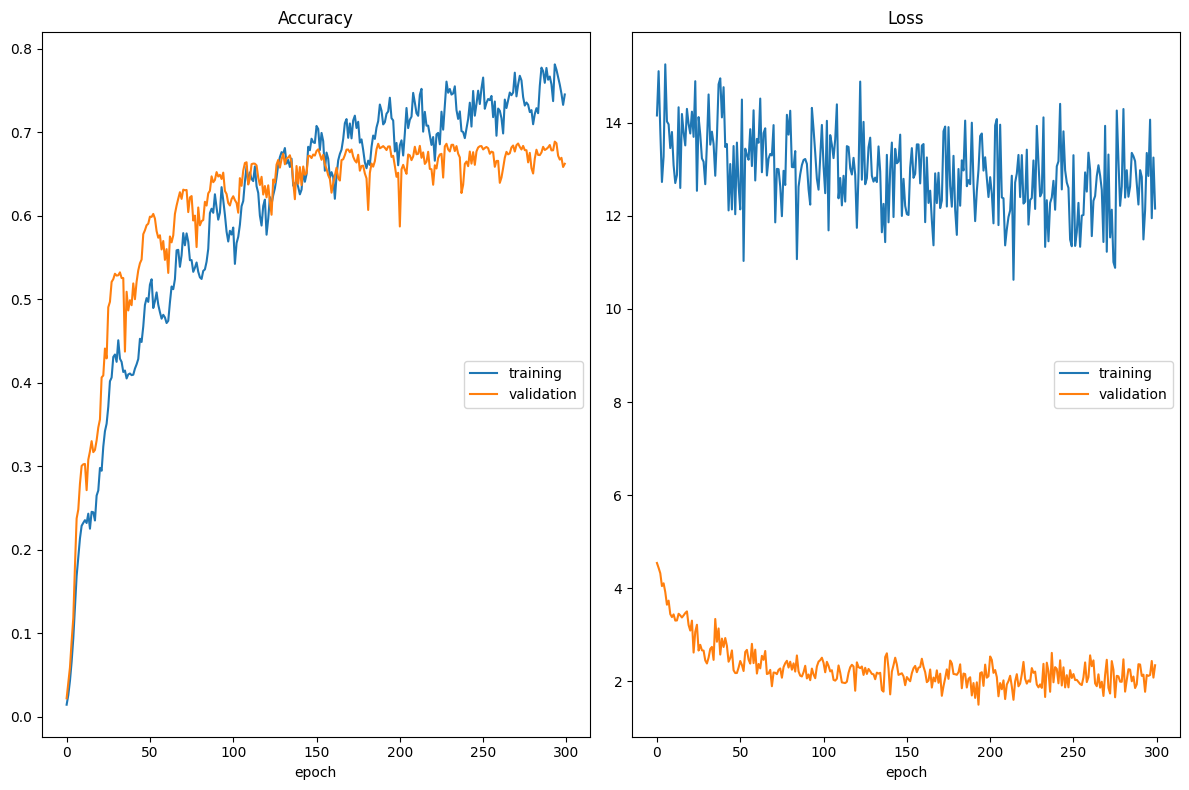

Accuracy
	training         	 (min:    0.015, max:    0.781, cur:    0.745)
	validation       	 (min:    0.022, max:    0.689, cur:    0.662)
Loss
	training         	 (min:   10.626, max:   15.255, cur:   12.157)
	validation       	 (min:    1.497, max:    4.542, cur:    2.344)


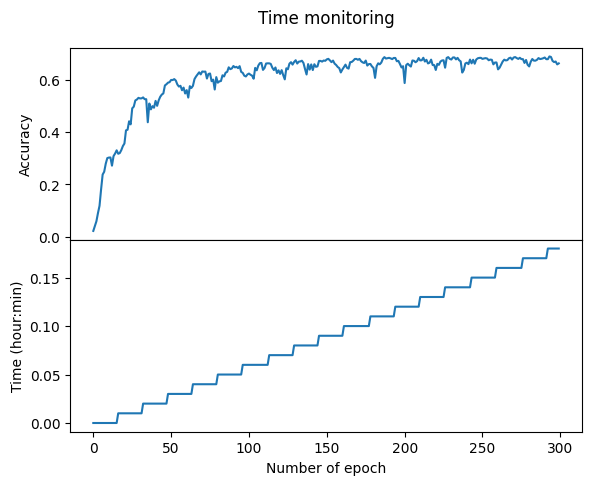

In [35]:

trainer_obj.run(train_dl, test_dl, EPOCH)

In [36]:

EPOCH = 300
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model.reset_parameters()
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-9)
model_name = "svhn_32x32_out100_adam_lr1e_4_sh_ca.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
callbacks = [PlotLossesKeras(), TimeAccuracy(), SaveBestAccVal(model, model_path), SaveHistory(history_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transforms=transform, 
        all_transforms=all_transform,
        lr_scheduler=lr_scheduler)

Using device: cuda


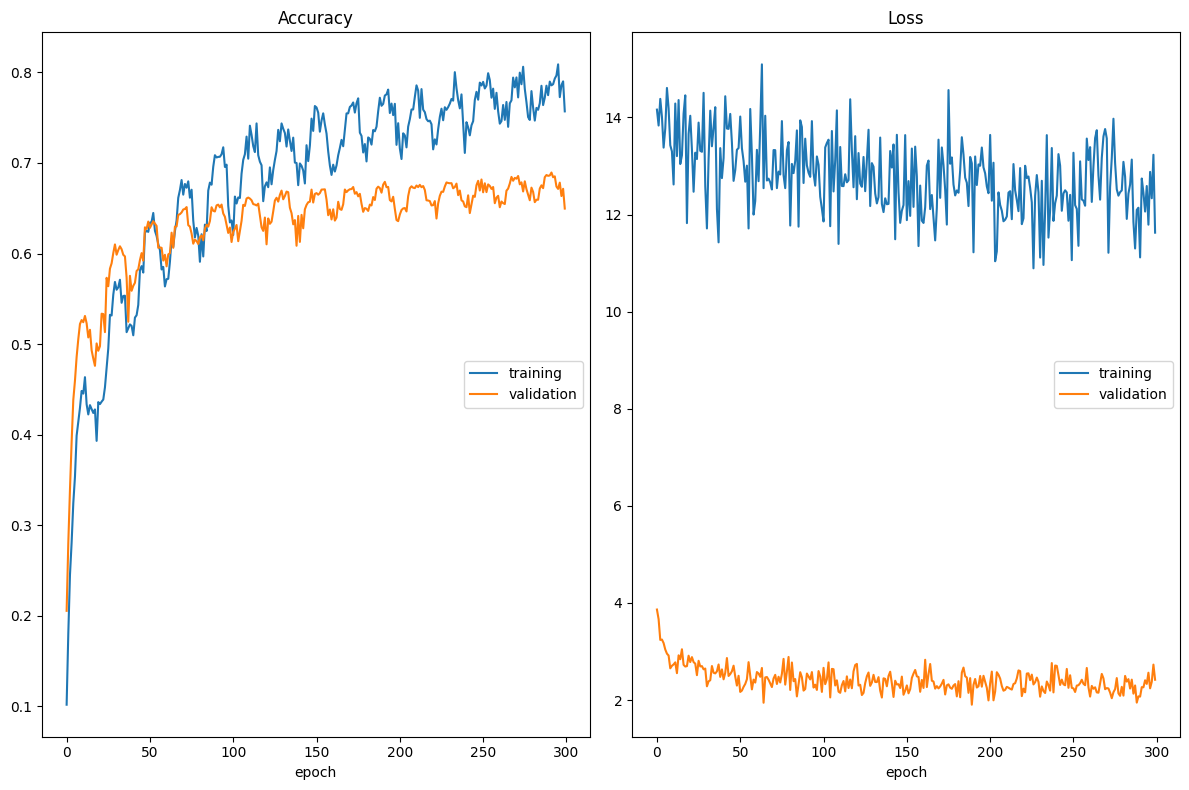

Accuracy
	training         	 (min:    0.102, max:    0.809, cur:    0.757)
	validation       	 (min:    0.205, max:    0.689, cur:    0.650)
Loss
	training         	 (min:   10.892, max:   15.093, cur:   11.626)
	validation       	 (min:    1.905, max:    3.865, cur:    2.419)


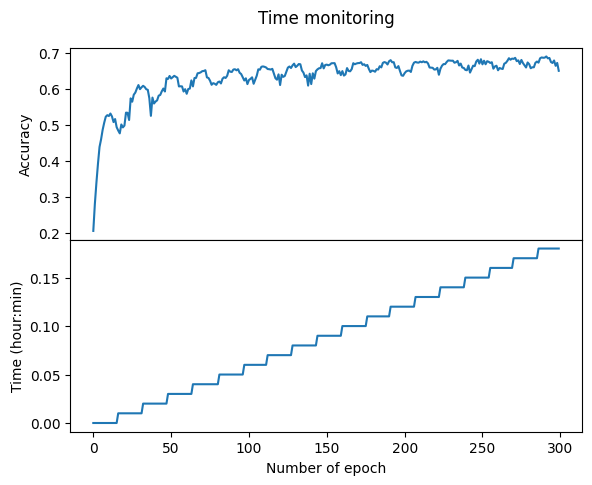

In [37]:

trainer_obj.run(train_dl, test_dl, EPOCH)

In [40]:

EPOCH = 300
model.reset_parameters()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-8)
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[150, 225], gamma=0.1)
model_name = "svhn_32x32_out100_sgd_lr1e_1_sh_ms.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
callbacks = [PlotLossesKeras(), TimeAccuracy(), SaveBestAccVal(model, model_path), SaveHistory(history_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transforms=transform, 
        all_transforms=all_transform,
        lr_scheduler=lr_scheduler)


Using device: cuda


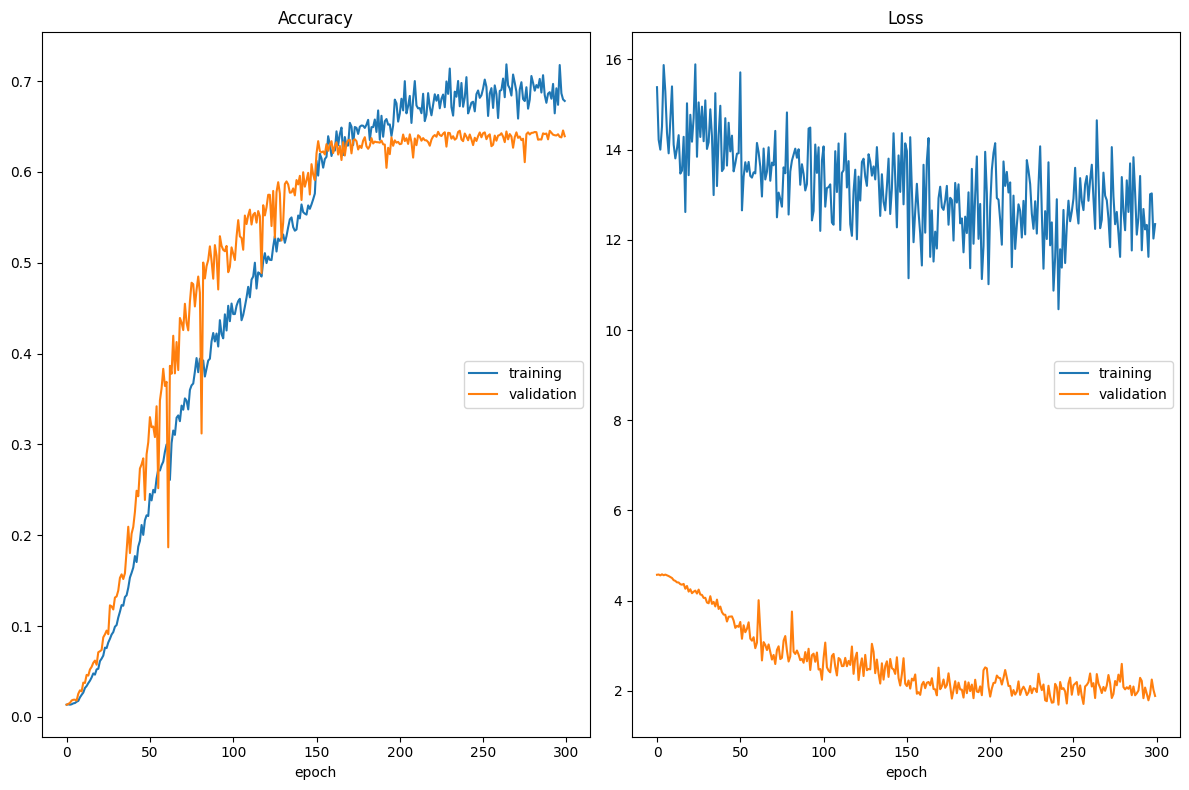

Accuracy
	training         	 (min:    0.013, max:    0.718, cur:    0.678)
	validation       	 (min:    0.013, max:    0.646, cur:    0.639)
Loss
	training         	 (min:   10.462, max:   15.892, cur:   12.350)
	validation       	 (min:    1.693, max:    4.584, cur:    1.886)


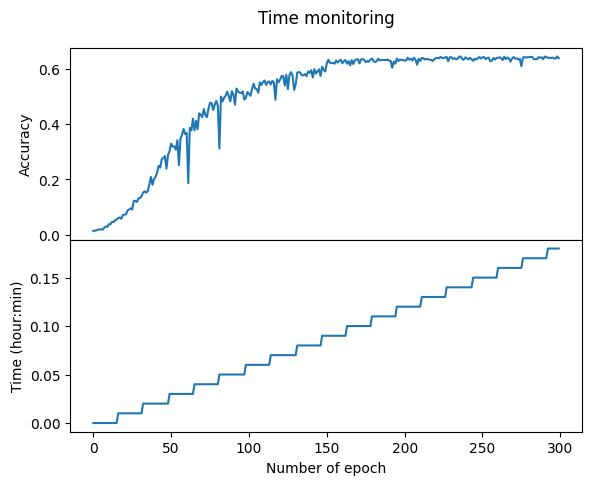

In [41]:

trainer_obj.run(train_dl, test_dl, EPOCH)

### Post procesing

In [24]:

model = VGG13(3,  train_ds.num_classes)

model_name = "svhn_32x32_out100_adam_lr1e_3.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
tmp_model = torch.load(model_path, weights_only=True)
model.load_state_dict(tmp_model["model_state_dict"])

<All keys matched successfully>

In [52]:

tta_obj = TTA(model, [
    "translate",
    "adjust_brightness",
    "adjust_contrast",
    "adjust_saturation",
    "adjust_hue",])

in_shape = (1, 3, 32, 32)
def build_model():
    return VGG13(3,  train_ds.num_classes)
select_model_obj = SelectModelType(model_path, build_model, in_shape=in_shape)

finetune_tta_obj = FinetuneTTA(test_dl, tta_obj, select_model_obj)

#### Speed test

In [49]:

model_types = (
    "raw",
    "scripted",
    "scripted",
    "traced",
    "traced",
    "frozen",
    "frozen",
    "optimized_for_inference",
    "optimized_for_inference",
    "compiled",
    "compiled",
)
dtypes = (
    torch.bfloat16,
    torch.half,
    torch.float32
)
tta_types = (
    "basic",
)
devices = (
    torch.device("cuda"),
    torch.device("cpu"),
)
# do speed test
#finetune_tta_obj(model_types, dtypes, tta_types, devices)
speed_prety_table_obj = finetune_tta_obj.by(model_types, dtypes, tta_types, devices, 
                    ord_prod=dict(model_type=3, dtype=1, tta_type=2, device=0),)

Speed experiments:   0%|          | 0/66 [00:00<?, ?it/s]

| Device |     Dtype      | TTA Type |        Model Type       | Accuracy |      Elapsed       |
| :----: | :------------: | :------: | :---------------------: | :------: | :----------------: |
|  cuda  | torch.bfloat16 |  basic   |           raw           |  0.6868  | 0.5281995849609376 |
|  cuda  | torch.bfloat16 |  basic   |         scripted        |  0.6868  | 0.5397733154296875 |
|  cuda  | torch.bfloat16 |  basic   |         scripted        |  0.6868  | 0.5062463073730469 |
|  cuda  | torch.bfloat16 |  basic   |          traced         |  0.6868  | 0.5339443969726563 |
|  cuda  | torch.bfloat16 |  basic   |          traced         |  0.6868  | 0.5263194580078125 |
|  cuda  | torch.bfloat16 |  basic   |          frozen         |  0.6872  | 0.5119678344726563 |
|  cuda  | torch.bfloat16 |  basic   |          frozen         |  0.6872  | 0.5110104370117188 |
|  cuda  | torch.bfloat16 |  basic   | optimized_for_inference |  0.6866  | 0.6414347534179687 |
|  cuda  | torch.bfloat16 |  b

#### Test-Time Augmentation (TTA)

In [53]:

model_types = (
    "scripted",
)
dtypes = (
    torch.bfloat16,
    torch.half,
    torch.float32
)
tta_types = (
    "basic",
    "mirror",
    "translate",
    "mirroring_and_translate",
    "rotate",
    "gray",
    "adjust_brightness",
    "adjust_contrast",
    "adjust_saturation",
    "adjust_hue",
    "mixt",
)
devices = (
    torch.device("cuda"),
)
# do tta test
#finetune_tta_obj(model_types, dtypes, tta_types, devices)
#
tta_prety_table_obj = finetune_tta_obj.by(model_types, dtypes, tta_types, devices, 
                    ord_prod=dict(model_type=2, dtype=1, tta_type=3, device=0),)

Speed experiments:   0%|          | 0/33 [00:00<?, ?it/s]

| Device |     Dtype      |         TTA Type        | Model Type | Accuracy | Elapsed |
| :----: | :------------: | :---------------------: | :--------: | :------: | :-----: |
|  cuda  | torch.bfloat16 |          basic          |  scripted  |  0.6868  |  0.6201 |
|  cuda  | torch.bfloat16 |          mirror         |  scripted  |  0.6877  |  0.7215 |
|  cuda  | torch.bfloat16 |        translate        |  scripted  |  0.6939  |  0.6903 |
|  cuda  | torch.bfloat16 | mirroring_and_translate |  scripted  |  0.6938  |  1.2706 |
|  cuda  | torch.bfloat16 |          rotate         |  scripted  |  0.2988  |  0.7198 |
|  cuda  | torch.bfloat16 |           gray          |  scripted  |  0.6521  |  0.6425 |
|  cuda  | torch.bfloat16 |    adjust_brightness    |  scripted  |  0.4611  |  0.6994 |
|  cuda  | torch.bfloat16 |     adjust_contrast     |  scripted  |  0.4688  |  0.6993 |
|  cuda  | torch.bfloat16 |    adjust_saturation    |  scripted  |  0.4598  |  0.7275 |
|  cuda  | torch.bfloat16 |     

## Classification help dataset

### Data aquisition

In [161]:

SAMPLES_PER_CLASS = 500
help_from = VIRTUAL_CLASS * SAMPLES_PER_CLASS / 50000
train_ds = AppendHelpDatasets(svhn_train_meta_ds, help_metads=help_metads, 
                              transform=get_init_transform(True,  IMAGE_SIZE, mean, std), 
                              help_from=0.5)
test_ds  = AppendHelpDatasets(svhn_test_meta_ds, help_metads=None, 
                              transform=get_init_transform(False, IMAGE_SIZE, mean, std), 
                              help_from=0)

print("train_ds {}, \ntest_ds {}".format(train_ds, test_ds))

train_ds AddHelpDatasets:
   size: 75000,
   num_classes : 147,
   virtual size: 25000,
   size per help dataset: 12500,
   size per help class:   531.9148936170212,
   
name: main,
   data_reader: RowDataset:
   name: SVHN train,
   size: 50000,
   num_classes : 100,
   shape: (50000, 32, 32, 3),
   in min: 0,
   in max: 255,
   out min: 0,
   out max: 99,, 
   target_shift: 0,
   dataset size: 50000,
   
name: cifar10,
   data_reader: Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Test, 
   target_shift: 100,
   dataset size: 10000,
   
name: oxfordIIIPet,
   data_reader: Dataset OxfordIIITPet
    Number of datapoints: 3669
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data, 
   target_shift: 110,
   dataset size: 3669,
   , 
test_ds AddHelpDatasets:
   size: 10000,
   num_classes : 100,
   virtual size: 0,
   size per help dataset: 0,
   size per hel

In [162]:
train_ds.num_classes

147

In [163]:

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = ()
for idx in range(1000):
    inputs, outputs = train_ds[idx]
    tensor_check(inputs,  in_shape,  255, 0, torch.uint8, arr_type=torchvision.tv_tensors._image.Image)
    tensor_check(outputs, out_shape,  train_ds.num_classes, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

for idx in range(1000):
    inputs, outputs = test_ds[idx]
    tensor_check(inputs,  in_shape,  2.4, -2.4, torch.float32, arr_type=torchvision.tv_tensors._image.Image)
    tensor_check(outputs, out_shape,  train_ds.num_classes, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

OK
OK


In [164]:

times = []
freeze_support()
for num_workers in range(33):
    _, t0 = time_mon_load_data(test_ds, num_workers, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    times.append(t0)
print("argmin {}".format(np.argmin(times)))


times = []
freeze_support()
for num_workers in range(33):
    _, t0 = time_mon_load_data(train_ds, num_workers, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    times.append(t0)
print("argmin {}".format(np.argmin(times)))

time_mon_load_data(AppendHelpDatasets[10000], 0) -> total time: 0.717431167s
time_mon_load_data(AppendHelpDatasets[10000], 1) -> total time: 0.958624448s
time_mon_load_data(AppendHelpDatasets[10000], 2) -> total time: 0.553894071s
time_mon_load_data(AppendHelpDatasets[10000], 3) -> total time: 0.450602044s
time_mon_load_data(AppendHelpDatasets[10000], 4) -> total time: 0.559592273s
time_mon_load_data(AppendHelpDatasets[10000], 5) -> total time: 0.558709775s
time_mon_load_data(AppendHelpDatasets[10000], 6) -> total time: 0.510038456s
time_mon_load_data(AppendHelpDatasets[10000], 7) -> total time: 0.539848427s
time_mon_load_data(AppendHelpDatasets[10000], 8) -> total time: 0.514975161s
time_mon_load_data(AppendHelpDatasets[10000], 9) -> total time: 0.526239989s
time_mon_load_data(AppendHelpDatasets[10000], 10) -> total time: 0.535417740s
time_mon_load_data(AppendHelpDatasets[10000], 11) -> total time: 0.555274052s
time_mon_load_data(AppendHelpDatasets[10000], 12) -> total time: 0.5652762

In [165]:

# select the best number workers
test_dl  = DataLoader(test_ds , batch_size=BATCH_SIZE, shuffle=False, num_workers=3, drop_last=False)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=21, drop_last=False)

In [166]:

transform     = get_transforms(IMAGE_SIZE, mean, std)
all_transform = get_all_transforms(num_classes=train_ds.num_classes)
print(all_transform)
in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, train_ds.num_classes)
print("in_shape {}, out_shape {}".format(in_shape, out_shape))
for idx, (inputs, outputs) in zip(range(1000), train_dl):
    tensor_check(inputs, in_shape, 255, 0, torch.uint8, arr_type=torch.Tensor)
    x    = transform(inputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    x, y = all_transform(x, outputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    tensor_check(y, out_shape, 1., 0., torch.float32)
else:
    print("OK")

RandomChoice(transforms=[CutMix(alpha=1.0), MixUp(alpha=1.0), LabelSmoothing(on_value=0.87, smooth_size=0.13)], p=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333])
in_shape (24, 3, 32, 32), out_shape (24, 147)
OK


In [167]:

in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, )
for idx, (inputs, outputs) in zip(range(50), test_dl):
    tensor_check(inputs,  in_shape, 2.4, -2.4, torch.float32)
    tensor_check(outputs, out_shape, train_ds.num_classes, 0, torch.int64)
else:
    print("OK")

OK


In [168]:
train_ds.num_classes

147

### Fit

In [169]:

model = VGG13(train_ds.num_classes)
criterion = nn.CrossEntropyLoss()

device = torch.device("cuda")

In [170]:

EPOCH = 300
optimizer    = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)
model_name = "svhn_32x32_out147_adam_lr1e_3.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
callbacks = [PlotLossesKeras(), TimeAccuracy(), SaveBestAccVal(model, model_path), SaveHistory(history_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transforms=transform, 
        all_transforms=all_transform,
        lr_scheduler=lr_scheduler)

Using device: cuda


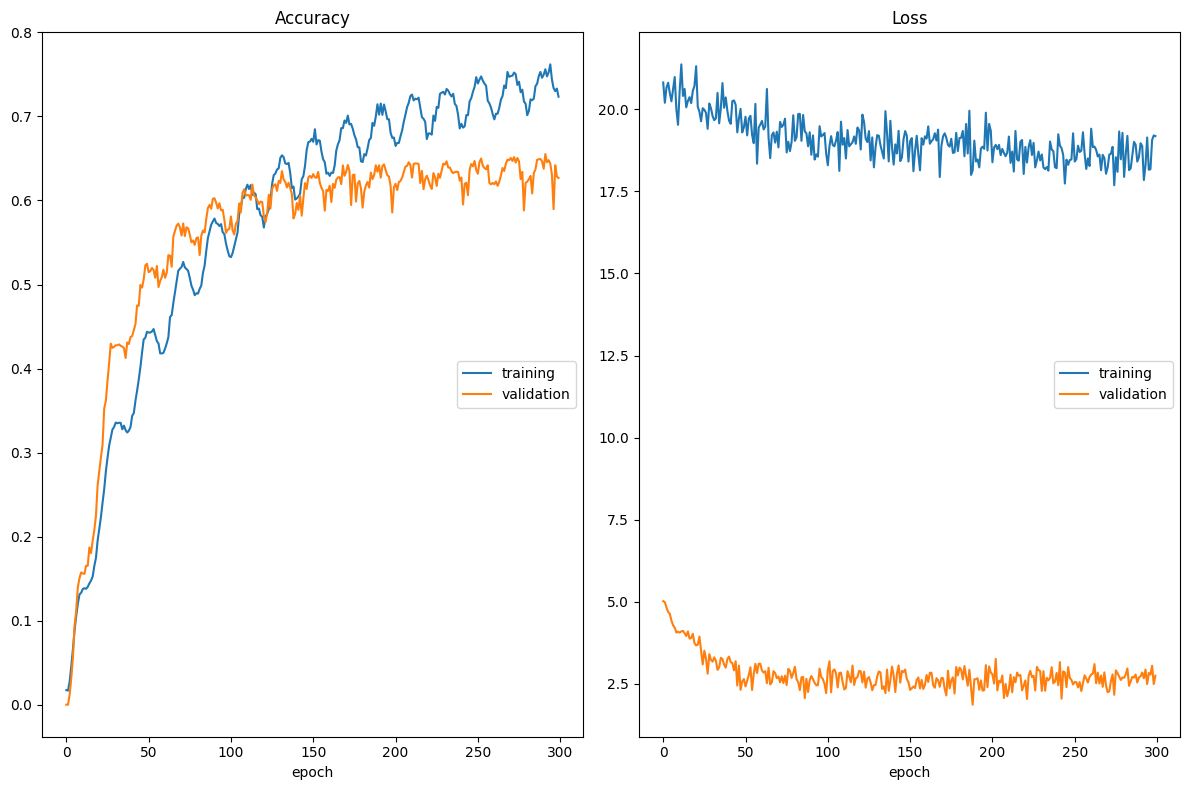

Accuracy
	training         	 (min:    0.017, max:    0.762, cur:    0.723)
	validation       	 (min:    0.000, max:    0.655, cur:    0.627)
Loss
	training         	 (min:   17.690, max:   21.373, cur:   19.186)
	validation       	 (min:    1.861, max:    5.018, cur:    2.744)


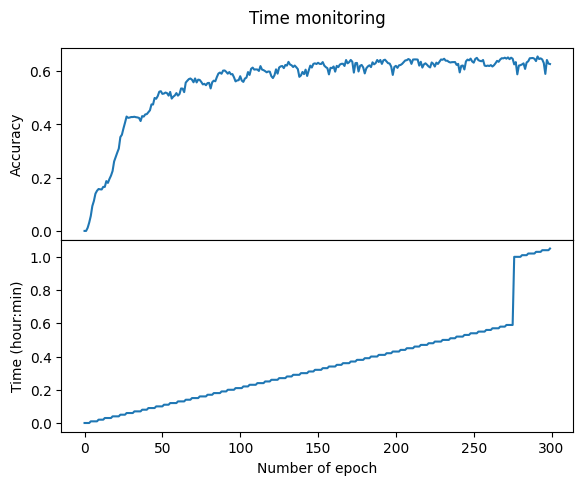

In [171]:

trainer_obj.run(train_dl, test_dl, EPOCH)

In [172]:

EPOCH = 300
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model.reset_parameters()
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-9)
model_name = "svhn_32x32_out147_adam_lr1e_4_sh_ca.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
callbacks = [PlotLossesKeras(), TimeAccuracy(), SaveBestAccVal(model, model_path), SaveHistory(history_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transforms=transform, 
        all_transforms=all_transform,
        lr_scheduler=lr_scheduler)

Using device: cuda


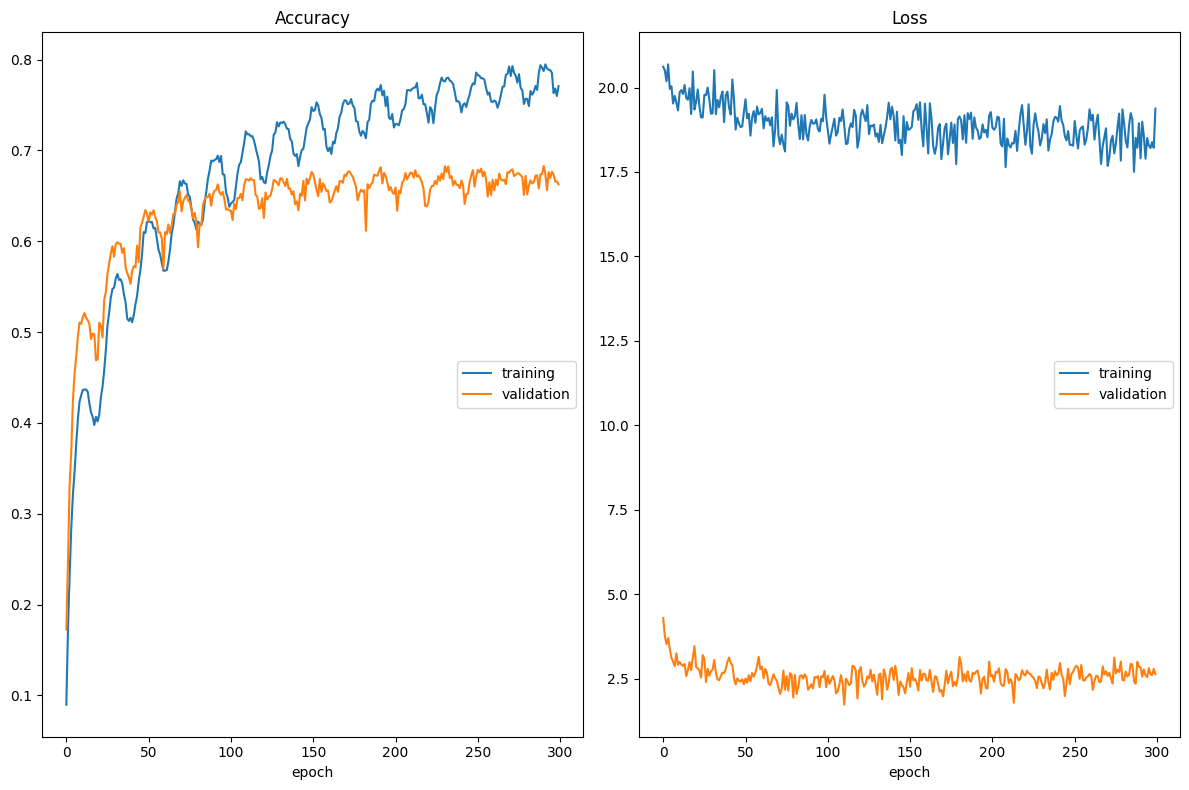

Accuracy
	training         	 (min:    0.090, max:    0.795, cur:    0.771)
	validation       	 (min:    0.173, max:    0.683, cur:    0.663)
Loss
	training         	 (min:   17.505, max:   20.687, cur:   19.377)
	validation       	 (min:    1.727, max:    4.294, cur:    2.631)


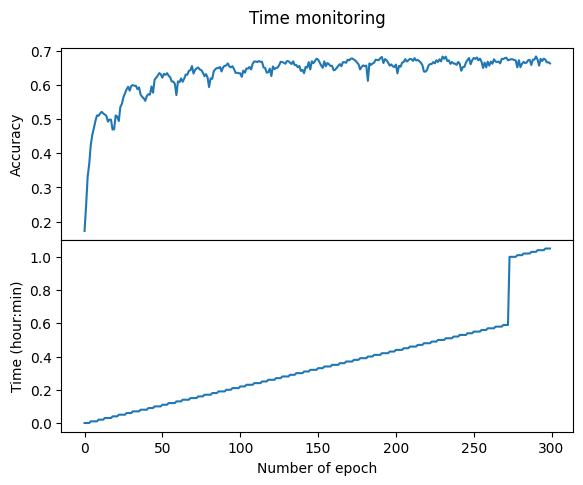

In [173]:

trainer_obj.run(train_dl, test_dl, EPOCH)

## Classification virtual dataset

### Data aquisition

In [58]:

train_ds = AddVirtualDatasets(svhn_train_meta_ds, help_metads=help_metads, 
                              transform=get_init_transform(True,  IMAGE_SIZE, mean, std), 
                              help_from=0.1)
test_ds  = AddVirtualDatasets(svhn_test_meta_ds, help_metads=None, 
                              transform=get_init_transform(False, IMAGE_SIZE, mean, std), 
                              help_from=0)

print("train_ds {}, \ntest_ds {}".format(train_ds, test_ds))

train_ds AddVirtualDatasets:
   size: 55000,
   num_classes : 100,
   virtual size: 5000,
   size per help dataset: 2500,
   
name: main,
   data_reader: RowDataset:
   name: SVHN train,
   size: 50000,
   num_classes : 100,
   shape: (50000, 32, 32, 3),
   in min: 0,
   in max: 255,
   out min: 0,
   out max: 99,, 
   dataset size: 50000,
   
name: cifar10,
   data_reader: Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Test, 
   dataset size: 10000,
   
name: oxfordIIIPet,
   data_reader: Dataset OxfordIIITPet
    Number of datapoints: 3669
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data, 
   dataset size: 3669,
   , 
test_ds AddVirtualDatasets:
   size: 10000,
   num_classes : 100,
   virtual size: 0,
   size per help dataset: 0,
   
name: main,
   data_reader: RowDataset:
   name: SVHN test,
   size: 10000,
   num_classes : 100,
   shape: (10000, 

In [59]:
train_ds.num_classes

100

In [60]:

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = ()
for idx in range(1000):
    inputs, outputs = train_ds[idx]
    tensor_check(inputs,  in_shape,  255, 0, torch.uint8, arr_type=torchvision.tv_tensors._image.Image)
    tensor_check(outputs, out_shape,  train_ds.num_classes, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

for idx in range(1000):
    inputs, outputs = test_ds[idx]
    tensor_check(inputs,  in_shape,  2.4, -2.4, torch.float32, arr_type=torchvision.tv_tensors._image.Image)
    tensor_check(outputs, out_shape,  train_ds.num_classes, 0, np.int64, arr_type=np.int64)
else:
    print("OK")

OK
OK


In [61]:

# select the best number workers
test_dl  = DataLoader(test_ds , batch_size=BATCH_SIZE, shuffle=False, num_workers=3, drop_last=False)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=21, drop_last=False)

In [64]:

transform     = get_transforms(IMAGE_SIZE, mean, std)
all_transform = get_all_transforms_smothing(num_classes=train_ds.num_classes)
print(all_transform)
in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, train_ds.num_classes)
print("in_shape {}, out_shape {}".format(in_shape, out_shape))
for idx, (inputs, outputs) in zip(range(100), train_dl):
    tensor_check(inputs, in_shape, 255, 0, torch.uint8, arr_type=torch.Tensor)
    x    = transform(inputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    x, y = all_transform(x, outputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    tensor_check(y, out_shape, 1., 0., torch.float32)
else:
    print("OK")

RandomChoice(transforms=[CutMix(alpha=1.0), MixUp(alpha=1.0), LabelSmoothing(on_value=0.87, smooth_size=0.13)], p=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333])
in_shape (128, 3, 32, 32), out_shape (128, 100)
OK


In [65]:

in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, )
for idx, (inputs, outputs) in zip(range(50), test_dl):
    tensor_check(inputs,  in_shape, 2.4, -2.4, torch.float32)
    tensor_check(outputs, out_shape, train_ds.num_classes, 0, torch.int64)
else:
    print("OK")

OK


### Fit

In [67]:

model = VGG13(3, train_ds.num_classes)
criterion = nn.CrossEntropyLoss()

device = torch.device("cuda")

In [197]:

EPOCH = 300
optimizer    = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)
model_name = "svhn_32x32_out100_virtual_adam_lr1e_3.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
callbacks = [PlotLossesKeras(), TimeAccuracy(), SaveBestAccVal(model, model_path), SaveHistory(history_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transforms=transform, 
        all_transforms=all_transform,
        lr_scheduler=lr_scheduler)

Using device: cuda


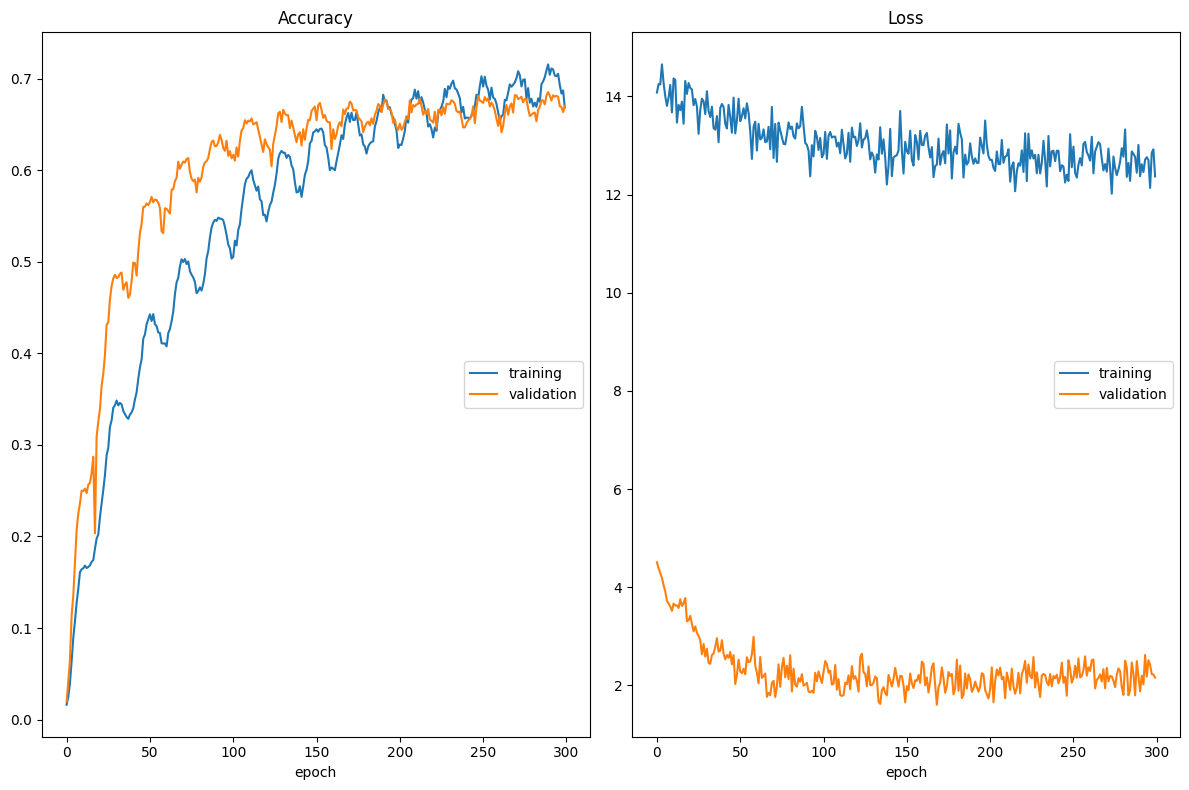

Accuracy
	training         	 (min:    0.016, max:    0.716, cur:    0.668)
	validation       	 (min:    0.020, max:    0.685, cur:    0.670)
Loss
	training         	 (min:   12.017, max:   14.653, cur:   12.370)
	validation       	 (min:    1.607, max:    4.509, cur:    2.160)


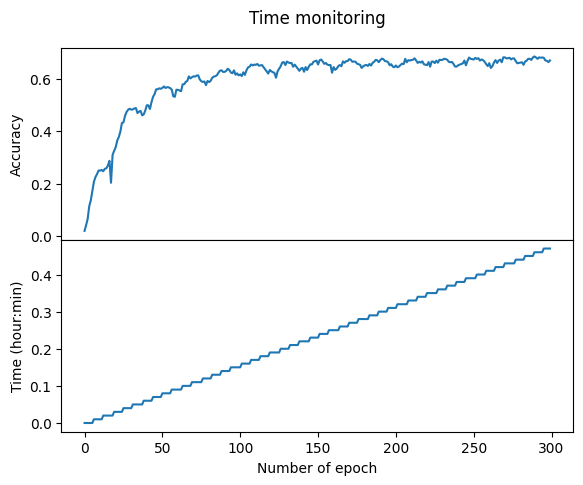

In [198]:

trainer_obj.run(train_dl, test_dl, EPOCH)

In [199]:

EPOCH = 300
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model.reset_parameters()
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-9)
model_name = "svhn_32x32_out100_virtual_adam_lr1e_4_sh_ca.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
callbacks = [PlotLossesKeras(), TimeAccuracy(), SaveBestAccVal(model, model_path), SaveHistory(history_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transforms=transform, 
        all_transforms=all_transform,
        lr_scheduler=lr_scheduler)

Using device: cuda


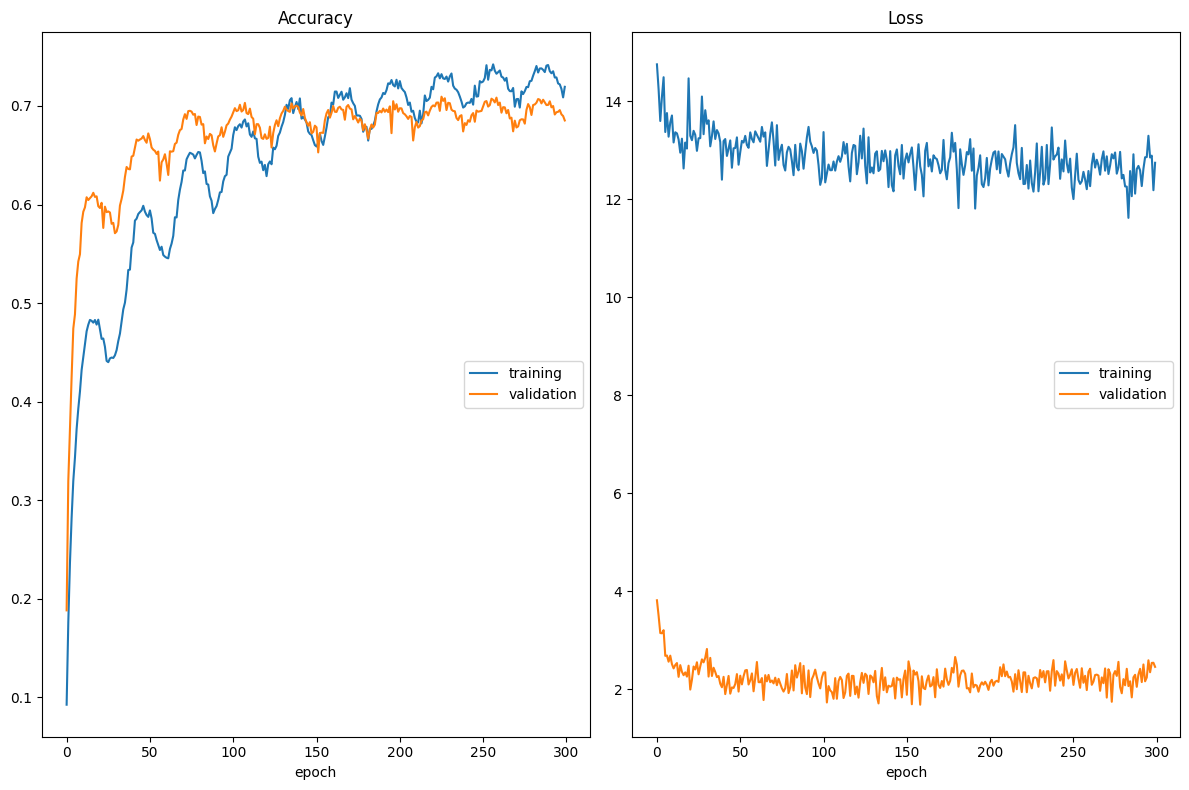

Accuracy
	training         	 (min:    0.092, max:    0.742, cur:    0.719)
	validation       	 (min:    0.188, max:    0.709, cur:    0.685)
Loss
	training         	 (min:   11.617, max:   14.749, cur:   12.741)
	validation       	 (min:    1.685, max:    3.815, cur:    2.457)


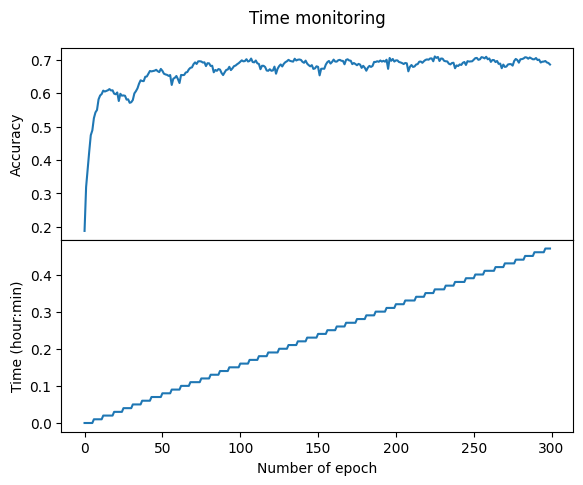

In [200]:

trainer_obj.run(train_dl, test_dl, EPOCH)

In [68]:

EPOCH = 300
model.reset_parameters()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-9)
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[150, 225], gamma=0.1)
model_name = "svhn_32x32_out100_virtual_sgd_lr1e_4_sh_ms.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
callbacks = [PlotLossesKeras(), TimeAccuracy(), SaveBestAccVal(model, model_path), SaveHistory(history_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="raw",
        transforms=transform, 
        all_transforms=all_transform,
        lr_scheduler=lr_scheduler)


2026-01-20 18:52:01.377782: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-20 18:52:01.530324: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768927921.589813  428383 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768927921.606910  428383 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768927921.743066  428383 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Using device: cuda


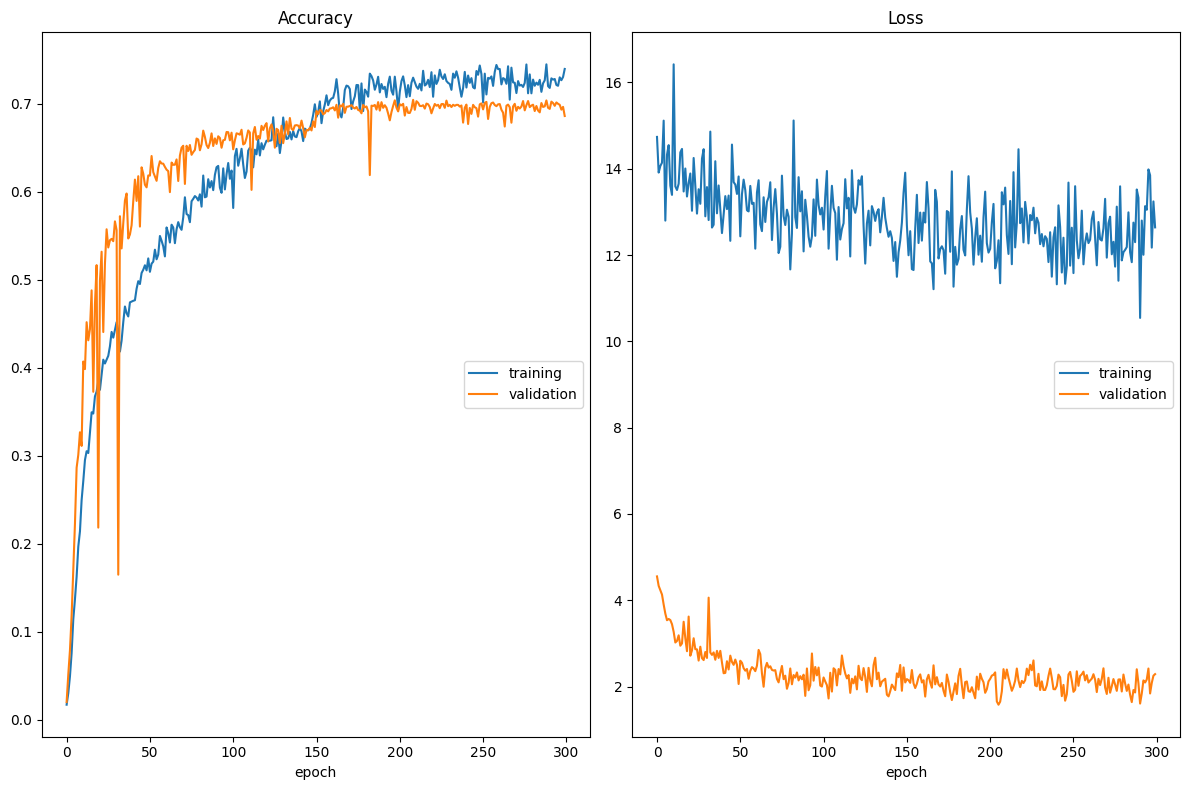

Accuracy
	training         	 (min:    0.017, max:    0.745, cur:    0.740)
	validation       	 (min:    0.020, max:    0.705, cur:    0.686)
Loss
	training         	 (min:   10.542, max:   16.418, cur:   12.640)
	validation       	 (min:    1.581, max:    4.553, cur:    2.289)


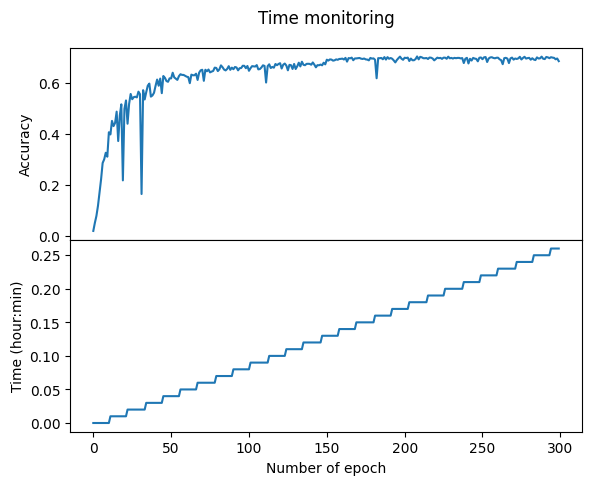

In [69]:

trainer_obj.run(train_dl, test_dl, EPOCH)

### Post procesing

In [54]:

model = VGG13(3,  train_ds.num_classes)

model_name = "svhn_32x32_out100_virtual_adam_lr1e_4_sh_ca.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
tmp_model = torch.load(model_path, weights_only=True)
model.load_state_dict(tmp_model["model_state_dict"])

<All keys matched successfully>

In [55]:

tta_obj = TTA(model, [
    "translate",
    "adjust_brightness",
    "adjust_contrast",
    "adjust_saturation",
    "adjust_hue",])

in_shape = (1, 3, 32, 32)
def build_model():
    return VGG13(3,  train_ds.num_classes)
select_model_obj = SelectModelType(model_path, build_model, in_shape=in_shape)

finetune_tta_obj = FinetuneTTA(test_dl, tta_obj, select_model_obj)

#### Speed test

In [56]:

model_types = (
    "raw",
    "scripted",
    "scripted",
    "traced",
    "traced",
    "frozen",
    "frozen",
    "optimized_for_inference",
    "optimized_for_inference",
    "compiled",
    "compiled",
)
dtypes = (
    torch.bfloat16,
    torch.half,
    torch.float32
)
tta_types = (
    "basic",
)
devices = (
    torch.device("cuda"),
    torch.device("cpu"),
)
# do speed test
speed_prety_table_obj = finetune_tta_obj.by(model_types, dtypes, tta_types, devices, 
                    ord_prod=dict(model_type=3, dtype=1, tta_type=2, device=0),)

Speed experiments:   0%|          | 0/66 [00:00<?, ?it/s]

[2026-01-20 18:39:48,476] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-01-20 18:39:48,476] torch._dynamo.convert_frame: [WARNING]    function: 'forward' (/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning/models/supervised/vgg13.py:66)
[2026-01-20 18:39:48,476] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-01-20 18:39:48,476] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-01-20 18:39:48,476] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/compile/troubleshooting.html.


| Device |     Dtype      | TTA Type |        Model Type       | Accuracy | Elapsed |
| :----: | :------------: | :------: | :---------------------: | :------: | :-----: |
|  cuda  | torch.bfloat16 |  basic   |           raw           |  0.7092  |  0.5752 |
|  cuda  | torch.bfloat16 |  basic   |         scripted        |  0.7092  |  0.5596 |
|  cuda  | torch.bfloat16 |  basic   |         scripted        |  0.7092  |  0.5579 |
|  cuda  | torch.bfloat16 |  basic   |          traced         |  0.7092  |  0.6119 |
|  cuda  | torch.bfloat16 |  basic   |          traced         |  0.7092  |  0.5952 |
|  cuda  | torch.bfloat16 |  basic   |          frozen         |  0.709   |  0.5604 |
|  cuda  | torch.bfloat16 |  basic   |          frozen         |  0.709   |  0.5636 |
|  cuda  | torch.bfloat16 |  basic   | optimized_for_inference |  0.7093  |  0.6843 |
|  cuda  | torch.bfloat16 |  basic   | optimized_for_inference |  0.7093  |  0.6781 |
|  cuda  | torch.bfloat16 |  basic   |         compile

#### Test-Time Augmentation (TTA)

In [70]:

model_types = (
    "frozen",
)
dtypes = (
    torch.bfloat16,
    torch.half,
    torch.float32
)
tta_types = (
    "basic",
    "mirror",
    "translate",
    "mirroring_and_translate",
)
devices = (
    torch.device("cuda"),
)
# do tta test
#finetune_tta_obj(model_types, dtypes, tta_types, devices)
#
tta_prety_table_obj = finetune_tta_obj.by(model_types, dtypes, tta_types, devices, 
                    ord_prod=dict(model_type=2, dtype=1, tta_type=3, device=0),)

Speed experiments:   0%|          | 0/33 [00:00<?, ?it/s]

| Device |     Dtype      |         TTA Type        | Model Type | Accuracy | Elapsed |
| :----: | :------------: | :---------------------: | :--------: | :------: | :-----: |
|  cuda  | torch.bfloat16 |          basic          |   frozen   |  0.709   |  0.6433 |
|  cuda  | torch.bfloat16 |          mirror         |   frozen   |  0.7146  |  0.7522 |
|  cuda  | torch.bfloat16 |        translate        |   frozen   |  0.714   |  0.725  |
|  cuda  | torch.bfloat16 | mirroring_and_translate |   frozen   |  0.7191  |  1.1869 |
|  cuda  | torch.bfloat16 |          rotate         |   frozen   |  0.3544  |  0.7457 |
|  cuda  | torch.bfloat16 |           gray          |   frozen   |  0.6773  |  0.6842 |
|  cuda  | torch.bfloat16 |    adjust_brightness    |   frozen   |  0.5134  |   0.72  |
|  cuda  | torch.bfloat16 |     adjust_contrast     |   frozen   |  0.5205  |  0.7667 |
|  cuda  | torch.bfloat16 |    adjust_saturation    |   frozen   |  0.5128  |  0.744  |
|  cuda  | torch.bfloat16 |     

## Classification Whiten

### Data aquisition

In [91]:

W_BATCH_SIZE = 3000
path = "{}/svhn_air_bench".format(DS_PATH)
MEAN_DS, STD_DS = train_in.mean(axis=(0, 1, 2)), train_in.std(axis=(0, 1, 2))
test_dl  = GpuRowDataLoader(path, test_in,  test_out,  False, MEAN_DS, STD_DS, batch_size=W_BATCH_SIZE, aug=None)
train_dl = GpuRowDataLoader(path, train_in, train_out, True,  MEAN_DS, STD_DS, batch_size=W_BATCH_SIZE, aug=dict(flip=True, translate=2))

### Fit

In [92]:

model = VGG13(24, train_dl.num_classes)
model = ApplyWhiten2d(model, 3).cuda().to(memory_format=torch.channels_last)
model.compile(mode="max-autotune")

train_images = train_dl.normalize(train_dl.images[:5000])
model.init_whiten(train_images)

criterion = nn.CrossEntropyLoss(reduction="sum", label_smoothing=0.2)
device = torch.device("cuda")

#### Version 0 BATCH_SIZE 2000

In [97]:

EPOCH = 50
whiten_bias_train_epochs = 30
total_train_steps = np.ceil(EPOCH * len(train_dl)).astype(int)
whiten_bias_train_steps = np.ceil(whiten_bias_train_epochs * len(train_dl)).astype(int)

bias_lr = 0.053
head_lr = 0.67
wd = 2e-6 * W_BATCH_SIZE
train_dl.setWorkMode("basic")
# Create optimizers and learning rate schedulers
filter_params = [p for p in model.parameters() if len(p.shape) == 4 and p.requires_grad]
norm_biases   = [p for n, p in model.named_parameters() if "norm" in n and p.requires_grad]
param_configs = [dict(params=[model.whiten.bias], lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=norm_biases,         lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=[model.head.weight], lr=head_lr, weight_decay=wd/head_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.85, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.24, momentum=0.6, nesterov=True, ns_steps=6)
optimizers = [optimizer1, optimizer2]
for opt in optimizers:
    for group in opt.param_groups:
        group["initial_lr"] = group["lr"]


In [98]:

total_train_steps = np.ceil(EPOCH * len(train_dl)).astype(int)
whiten_bias_train_steps = np.ceil(whiten_bias_train_epochs * len(train_dl)).astype(int)

scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=100, eta_min=0)
scheduler2 = torch.optim.lr_scheduler.MultiStepLR(optimizer1, milestones=[50, 75, 100, 125], gamma=0.1)
lr_scheduler1 = torch.optim.lr_scheduler.SequentialLR(
    optimizer1,
    schedulers=[scheduler1, scheduler2],
    milestones=[150],
)

lr_scheduler1 = torch.optim.lr_scheduler.LambdaLR(
    optimizer2,
    lr_lambda=lambda step: max(1e-7, 1 - step / whiten_bias_train_steps)
)

lr_scheduler2 = torch.optim.lr_scheduler.LambdaLR(
    optimizer2,
    lr_lambda=lambda step: max(1e-7, 1 - step / total_train_steps)
)
lr_schedulers = [lr_scheduler1, lr_scheduler2]

In [99]:

tta_obj = TTA(model, [])
tta_obj.select("mirroring_and_translate")
finetune_airbatch = FinetuneAirbatch(model, criterion, optimizers, lr_shedulers, tta_obj)

In [100]:
finetune_airbatch(train_dl, test_dl, EPOCH, 
                  work_modes=["warmup", 0, 1],
                  whiten_bias_train_epochs=whiten_bias_train_epochs, )

+--------+-------+-----------+---------+----------+--------------------+
|  run   | epoch | train_acc | val_acc | eval_acc |    time_seconds    |
+--------+-------+-----------+---------+----------+--------------------+
| warmup |   0   |  0.01026  |  0.0138 |          | 1.1766863250732422 |
| warmup |   1   |  0.00982  |  0.0125 |          | 2.2985087509155275 |
| warmup |   2   |  0.01022  |   0.01  |          | 3.432566867828369  |
| warmup |   3   |  0.00972  |   0.01  |          | 4.548291606903076  |
| warmup |   4   |  0.00946  |  0.0135 |          | 5.6487246589660645 |
| warmup |   5   |  0.00918  |   0.01  |          | 6.750633407592773  |
| warmup |   6   |  0.00996  |  0.0109 |          | 7.853454010009766  |
| warmup |   7   |  0.01092  |  0.0039 |          | 8.962554935455323  |
| warmup |   8   |  0.01032  |   0.01  |          | 10.068377918243408 |
| warmup |   9   |  0.01004  |  0.0061 |          | 11.175213871002196 |
| warmup |   10  |  0.00984  |  0.0107 |          |

#### Version 1 BATCH_SIZE 2000

In [101]:

EPOCH = 8
whiten_bias_train_epochs = 3
total_train_steps = np.ceil(EPOCH * len(train_dl)).astype(int)
whiten_bias_train_steps = np.ceil(whiten_bias_train_epochs * len(train_dl)).astype(int)

bias_lr = 0.053
head_lr = 0.67
wd = 2e-6 * W_BATCH_SIZE
train_dl.setWorkMode("basic")
# Create optimizers and learning rate schedulers
filter_params = [p for p in model.parameters() if len(p.shape) == 4 and p.requires_grad]
norm_biases   = [p for n, p in model.named_parameters() if "norm" in n and p.requires_grad]
param_configs = [dict(params=[model.whiten.bias], lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=norm_biases,         lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=[model.head.weight], lr=head_lr, weight_decay=wd/head_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.85, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.24, momentum=0.6, nesterov=True, ns_steps=6)
optimizers = [optimizer1, optimizer2]
for opt in optimizers:
    for group in opt.param_groups:
        group["initial_lr"] = group["lr"]
        
lr_sheduler1 = WhitenLrScheduler(optimizers, total_train_steps, whiten_bias_train_steps)
lr_shedulers = [lr_sheduler1]

In [103]:

tta_obj = TTA(model, [])
tta_obj.select("mirroring_and_translate")
finetune_airbatch = FinetuneAirbatch(model, criterion, optimizers, lr_shedulers, tta_obj)

finetune_airbatch(train_dl, test_dl, EPOCH, 
                  work_modes=[0, 1, 2],
                  whiten_bias_train_epochs=whiten_bias_train_epochs, )

+-----+-------+-----------+---------+----------+--------------------+
| run | epoch | train_acc | val_acc | eval_acc |    time_seconds    |
+-----+-------+-----------+---------+----------+--------------------+
|  0  |   0   |  0.10342  |  0.1311 |          | 1.1847088737487792 |
|  0  |   1   |  0.25628  |  0.2211 |          | 2.2879153175354006 |
|  0  |   2   |  0.36494  |  0.3168 |          | 3.392250213623047  |
|  0  |   3   |  0.44282  |  0.3938 |          | 4.505877548217773  |
|  0  |   4   |  0.51416  |  0.4704 |          | 5.610959896087647  |
|  0  |   5   |  0.58724  |  0.5537 |          | 6.697778400421143  |
|  0  |   6   |  0.65756  |  0.6252 |          | 7.798993103027343  |
|  0  |   7   |  0.72118  |  0.6542 |          |  8.8805830078125   |
|  0  |  tta  |           |         |  0.6536  | 9.375698272705078  |
+-----+-------+-----------+---------+----------+--------------------+
+-----+-------+-----------+---------+----------+--------------------+
| run | epoch | trai

#### Version 2 BATCH_SIZE 2000

In [99]:

EPOCH = 50
whiten_bias_train_epochs = 5
total_train_steps = np.ceil(EPOCH * len(train_dl)).astype(int)
whiten_bias_train_steps = np.ceil(whiten_bias_train_epochs * len(train_dl)).astype(int)

bias_lr = 0.053
head_lr = 0.97
wd = 2e-8 * W_BATCH_SIZE
train_dl.setWorkMode("basic")
# Create optimizers and learning rate schedulers
filter_params = [p for p in model.parameters() if len(p.shape) == 4 and p.requires_grad]
norm_biases   = [p for n, p in model.named_parameters() if "norm" in n and p.requires_grad]
param_configs = [dict(params=[model.whiten.bias], lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=norm_biases,         lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=[model.head.weight], lr=head_lr, weight_decay=wd/head_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.85, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.24, momentum=0.6, nesterov=True, ns_steps=6)
optimizers = [optimizer1, optimizer2]
for opt in optimizers:
    for group in opt.param_groups:
        group["initial_lr"] = group["lr"]
        
lr_sheduler1 = WhitenLrScheduler(optimizers, total_train_steps, whiten_bias_train_steps)
lr_shedulers = [lr_sheduler1]

In [100]:

tta_obj = TTA(model, [])
tta_obj.select("mirroring_and_translate")

model_name = "svhn_32x32_out100_fast_v2.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
finetune_airbatch = FinetuneAirbatch(model, criterion, optimizers, lr_shedulers, 
                                     tta_obj, model_path, 
                                     transforms=OneHotTarget(num_classes=train_dl.num_classes))

In [101]:
prety_table_obj = finetune_airbatch(train_dl, test_dl, EPOCH, 
                  work_modes=[0, 1],
                  whiten_bias_train_epochs=whiten_bias_train_epochs, )

Speed experiments:   0%|          | 0/2 [00:00<?, ?it/s]

In [102]:

prety_table_obj.set_style(TableStyle.MARKDOWN)
print(prety_table_obj)

| run | epoch | train_acc | val_acc | eval_acc | time_seconds |
| :-: | :---: | :-------: | :-----: | :------: | :----------: |
|  0  |   0   |    0.07   |  0.055  |          |    10.938    |
|  0  |   1   |   0.192   |  0.113  |          |    12.634    |
|  0  |   2   |   0.277   |  0.264  |          |    13.641    |
|  0  |   3   |   0.334   |  0.194  |          |    14.635    |
|  0  |   4   |   0.376   |  0.308  |          |    15.652    |
|  0  |   5   |   0.402   |  0.284  |          |    27.534    |
|  0  |   6   |   0.421   |  0.282  |          |    28.516    |
|  0  |   7   |   0.444   |  0.322  |          |    29.496    |
|  0  |   8   |   0.465   |  0.289  |          |    30.511    |
|  0  |   9   |   0.479   |  0.358  |          |    31.544    |
|  0  |   10  |   0.497   |  0.303  |          |    32.585    |
|  0  |   11  |   0.514   |  0.362  |          |    33.572    |
|  0  |   12  |   0.524   |  0.369  |          |    34.556    |
|  0  |   13  |   0.543   |  0.366  |   

#### Version 3 BATCH_SIZE 2000

In [104]:

EPOCH = 30
whiten_bias_train_epochs = 5
total_train_steps = np.ceil(EPOCH * len(train_dl)).astype(int)
whiten_bias_train_steps = np.ceil(whiten_bias_train_epochs * len(train_dl)).astype(int)

bias_lr = 0.053
head_lr = 0.97
wd = 2e-9 * W_BATCH_SIZE
train_dl.setWorkMode("basic")
# Create optimizers and learning rate schedulers
filter_params = [p for p in model.parameters() if len(p.shape) == 4 and p.requires_grad]
norm_biases   = [p for n, p in model.named_parameters() if "norm" in n and p.requires_grad]
param_configs = [dict(params=[model.whiten.bias], lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=norm_biases,         lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=[model.head.weight], lr=head_lr, weight_decay=wd/head_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.85, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.54, momentum=0.6, nesterov=True, ns_steps=6)
optimizers = [optimizer1, optimizer2]
for opt in optimizers:
    for group in opt.param_groups:
        group["initial_lr"] = group["lr"]
        
lr_sheduler1 = WhitenLrScheduler(optimizers, total_train_steps, whiten_bias_train_steps)
lr_shedulers = [lr_sheduler1]

In [106]:

tta_obj = TTA(model, [])
tta_obj.select("mirroring_and_translate")
finetune_airbatch = FinetuneAirbatch(model, criterion, optimizers, lr_shedulers, tta_obj)

finetune_airbatch(train_dl, test_dl, EPOCH, 
                  work_modes=[0, 1, 2],
                  whiten_bias_train_epochs=whiten_bias_train_epochs, )

+-----+-------+-----------+---------+----------+--------------------+
| run | epoch | train_acc | val_acc | eval_acc |    time_seconds    |
+-----+-------+-----------+---------+----------+--------------------+
|  0  |   0   |  0.05228  |  0.0514 |          | 1.1415878524780272 |
|  0  |   1   |   0.0866  |  0.062  |          | 2.2430956840515135 |
|  0  |   2   |  0.10206  |  0.0803 |          | 3.3720169525146484 |
|  0  |   3   |  0.11736  |  0.0791 |          | 4.4755401611328125 |
|  0  |   4   |  0.13338  |  0.0901 |          | 5.579627372741699  |
|  0  |   5   |  0.13856  |  0.0741 |          | 6.658939441680909  |
|  0  |   6   |  0.16068  |  0.0975 |          |  7.77010633468628  |
|  0  |   7   |   0.1722  |  0.1281 |          | 8.875433185577393  |
|  0  |   8   |  0.19352  |  0.1245 |          | 9.957910820007324  |
|  0  |   9   |  0.20476  |  0.1238 |          | 11.05628662109375  |
|  0  |   10  |   0.2204  |  0.151  |          | 12.158046905517578 |
|  0  |   11  |  0.2

#### Version 4 BATCH_SIZE 2000

In [42]:

EPOCH = 80
whiten_bias_train_epochs = 50
total_train_steps = np.ceil(EPOCH * len(train_dl)).astype(int)
whiten_bias_train_steps = np.ceil(whiten_bias_train_epochs * len(train_dl)).astype(int)

bias_lr = 0.053
norm_lr = 0.53
head_lr = 0.67
wd = 2e-9 * W_BATCH_SIZE
train_dl.setWorkMode("basic")
# Create optimizers and learning rate schedulers
filter_params = [p for p in model.parameters() if len(p.shape) == 4 and p.requires_grad]
norm_biases   = [p for p in list(model.parameters())[:-1] if len(p.shape) == 1 and p.requires_grad]
param_configs = [dict(params=[model.whiten.bias], lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=norm_biases,         lr=norm_lr, weight_decay=wd/bias_lr),
                 dict(params=[model.head.weight], lr=head_lr, weight_decay=wd/head_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.1, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.001, momentum=0.6, nesterov=True, ns_steps=3)
optimizers = [optimizer1, optimizer2]
for opt in optimizers:
    for group in opt.param_groups:
        group["initial_lr"] = group["lr"]
        
lr_scheduler1 = WhitenLrScheduler(optimizers, total_train_steps, whiten_bias_train_steps)
lr_schedulers = [lr_scheduler1]

In [46]:

tta_obj = TTA(model, [])
tta_obj.select("mirroring_and_translate")
finetune_airbatch = FinetuneAirbatch(model, criterion, optimizers, lr_schedulers, tta_obj,
                  transforms=OneHotTarget(num_classes=train_dl.num_classes))

finetune_airbatch(train_dl, test_dl, EPOCH, 
                  work_modes=[0, 1, 2],
                  whiten_bias_train_epochs=whiten_bias_train_epochs, )

[2026-01-18 02:26:56,484] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-01-18 02:26:56,484] torch._dynamo.convert_frame: [WARNING]    function: 'forward' (/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning/models/supervised/apply_whiten2d.py:67)
[2026-01-18 02:26:56,484] torch._dynamo.convert_frame: [WARNING]    last reason: ___check_global_state()
[2026-01-18 02:26:56,484] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-01-18 02:26:56,484] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/compile/troubleshooting.html.


+-----+-------+-----------+---------+----------+--------------+
| run | epoch | train_acc | val_acc | eval_acc | time_seconds |
+-----+-------+-----------+---------+----------+--------------+
|  0  |   0   |   0.041   |  0.015  |          |    1.026     |
|  0  |   1   |   0.101   |  0.025  |          |    2.038     |
|  0  |   2   |    0.15   |  0.031  |          |    3.101     |
|  0  |   3   |   0.187   |   0.04  |          |    4.116     |
|  0  |   4   |   0.215   |  0.125  |          |    5.153     |
|  0  |   5   |   0.244   |  0.152  |          |    6.185     |
|  0  |   6   |   0.263   |  0.016  |          |    7.212     |
|  0  |   7   |   0.281   |   0.1   |          |    8.288     |
|  0  |   8   |    0.3    |  0.113  |          |    9.344     |
|  0  |   9   |    0.32   |  0.133  |          |    10.385    |
|  0  |   10  |   0.337   |  0.048  |          |    11.432    |
|  0  |   11  |   0.352   |  0.043  |          |    12.505    |
|  0  |   12  |   0.366   |  0.151  |   

KeyboardInterrupt: 

#### Version 5 BATCH_SIZE 500

In [23]:

EPOCH = 80
whiten_bias_train_epochs = 10
total_train_steps = np.ceil(EPOCH * len(train_dl)).astype(int)
whiten_bias_train_steps = np.ceil(whiten_bias_train_epochs * len(train_dl)).astype(int)

bias_lr = 0.053
norm_lr = 0.0053
head_lr = 0.67
wd = 2e-9 * W_BATCH_SIZE
train_dl.setWorkMode("basic")
# Create optimizers and learning rate schedulers
filter_params = [p for p in list(model.parameters())[:-1] if len(p.shape) == 4 and p.requires_grad]
norm_biases   = [p for p in list(model.parameters())[:-1] if len(p.shape) == 1 and p.requires_grad]
param_configs = [#dict(params=[model.whiten.bias], lr=bias_lr, weight_decay=wd/bias_lr),
                 dict(params=norm_biases,         lr=norm_lr, weight_decay=wd/bias_lr),
                 dict(params=[model.head.weight], lr=head_lr, weight_decay=wd/head_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.85, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.54, momentum=0.6, nesterov=True, ns_steps=3)
optimizers = [optimizer1, optimizer2]
for opt in optimizers:
    for group in opt.param_groups:
        group["initial_lr"] = group["lr"]
        
lr_scheduler1 = WhitenLrScheduler(optimizers, total_train_steps, whiten_bias_train_steps)
lr_schedulers = [lr_scheduler1]

In [24]:

model_name = "svhn_32x32_out100_fast_sgd_muon.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
history_path = "{}/logs/history_{}.csv".format(LCL_PATH, Path(model_name).stem)
metrics   = {"acc": Acuracy(name="accuracy")}

#transform     = get_choice_transforms(IMAGE_SIZE)
transform     = None
#all_transform = get_all_transforms_onehot(train_dl.num_classes, p=[0.3, 0.3, 0.4])
all_transform = OneHotTarget(num_classes=train_dl.num_classes)

trainer_obj = GPUWhitenTrainer(
    model, 
    optimizers, 
    criterion, 
    device,
    metrics=metrics,
    model_type="raw",
    transforms=transform, 
    all_transforms=all_transform,
    lr_schedulers=lr_schedulers,
    whiten_bias_train_epochs=whiten_bias_train_epochs,
)

Using device: cuda


In [25]:

lr_scheduler1.reset()
model.reset_parameters()
trainer_obj.evaluate(test_dl)
trainer_obj.run(train_dl, test_dl, EPOCH, model_path)
trainer_obj.evaluate(test_dl)

Evaluate:   0%|          | 0/4 [00:00<?, ?it/s]

AUTOTUNE convolution(3000x3x33x33, 24x3x2x2)
  convolution 0.1955 ms 100.0%
  triton_convolution_4 0.2161 ms 90.5%
  triton_convolution_3 0.2458 ms 79.5%
  triton_convolution_0 0.2683 ms 72.9%
  triton_convolution_5 0.4225 ms 46.3%
  triton_convolution_1 0.4790 ms 40.8%
  triton_convolution_2 0.5180 ms 37.7%
SingleProcess AUTOTUNE takes 1.5479 seconds
AUTOTUNE convolution(3000x24x32x32, 64x24x3x3)
  convolution 0.7382 ms 100.0%
  triton_convolution_12 1.0710 ms 68.9%
  triton_convolution_7 1.1920 ms 61.9%
  triton_convolution_9 1.3824 ms 53.4%
  triton_convolution_11 2.0202 ms 36.5%
  triton_convolution_10 2.0234 ms 36.5%
  triton_convolution_6 2.2682 ms 32.5%
  triton_convolution_8 3.0628 ms 24.1%
SingleProcess AUTOTUNE takes 1.9188 seconds
AUTOTUNE convolution(3000x64x32x32, 64x64x3x3)
  convolution 1.4761 ms 100.0%
  triton_convolution_16 1.4985 ms 98.5%
  triton_convolution_17 1.6517 ms 89.4%
  triton_convolution_18 1.6844 ms 87.6%
  triton_convolution_14 1.8027 ms 81.9%
  triton_c

Running 80 epochs


Training:   0%|          | 0/80 [00:00<?, ?it/s]

AUTOTUNE convolution(3000x3x33x33, 24x3x2x2)
  convolution 0.1946 ms 100.0%
  triton_convolution_180 0.2140 ms 90.9%
  triton_convolution_179 0.2468 ms 78.8%
  triton_convolution_176 0.2662 ms 73.1%
  triton_convolution_181 0.2796 ms 69.6%
  triton_convolution_178 0.5304 ms 36.7%
  triton_convolution_177 0.5344 ms 36.4%
SingleProcess AUTOTUNE takes 0.8140 seconds
AUTOTUNE convolution(3000x24x32x32, 64x24x3x3)
  convolution 0.7396 ms 100.0%
  triton_convolution_188 1.2503 ms 59.1%
  triton_convolution_183 1.3947 ms 53.0%
  triton_convolution_185 1.7447 ms 42.4%
  triton_convolution_187 2.7546 ms 26.8%
  triton_convolution_186 2.7556 ms 26.8%
  triton_convolution_182 3.0853 ms 24.0%
  triton_convolution_184 3.2707 ms 22.6%
SingleProcess AUTOTUNE takes 1.0953 seconds
AUTOTUNE convolution(3000x64x32x32, 64x64x3x3)
  convolution 1.4418 ms 100.0%
  triton_convolution_192 1.5145 ms 95.2%
  triton_convolution_193 1.6824 ms 85.7%
  triton_convolution_194 1.7101 ms 84.3%
  triton_convolution_190

KeyboardInterrupt: 

In [19]:

in_shape = (1, 32, 32, 3)

tta_obj = TTA(model, [])
finetune_tta_obj = FinetuneTTA(model, test_dl, tta_obj, in_shape=in_shape)

In [20]:

model_types = (
    "raw",
    "scripted",
    "scripted",
    "traced",
    "traced",
    "frozen",
    "frozen",
    "optimized_for_inference",
    "optimized_for_inference",
    "compiled",
    "compiled",
)
dtypes = (
    torch.bfloat16,
    torch.half,
    torch.float32
)
tta_types = (
    "none",
)
devices = (
    torch.device("cuda"),
    torch.device("cpu"),
)
# do speed test
finetune_tta_obj(model_types, dtypes, tta_types, devices)

Speed experiments:   0%|          | 0/66 [00:00<?, ?it/s]

RuntimeError: 
'Optional[Tensor]' object has no attribute or method 'detach'.:
  File "/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning/models/supervised/apply_whiten2d.py", line 69
   def forward(self, x, whiten_bias_grad=True):
      b = self.whiten.bias
      b_used = b if whiten_bias_grad else b.detach()
                                          ~~~~~~~~ <--- HERE
      b_used = b_used.to(dtype=x.dtype)
      x = nn.functional.pad(x, self.pad, "constant", 0)


In [21]:

model_types = (
    "raw",
    #"scripted",
)
dtypes = (
    torch.bfloat16,
    torch.half,
    torch.float32
)
tta_types = (
    "basic",
    "mirroring",
    "translate",
    "mirroring_and_translate",
)
devices = (
    torch.device("cuda"),
)
# do tta test
finetune_tta_obj(model_types, dtypes, tta_types, devices)

Speed experiments:   0%|          | 0/12 [00:00<?, ?it/s]

+--------+----------------+----------+------------+----------+-------------+
| Device |     Dtype      | TTA Type | Model Type | Accuracy |   Elapsed   |
+--------+----------------+----------+------------+----------+-------------+
|  cuda  | torch.bfloat16 |  basic   |    raw     |   0.01   | 0.077939913 |
+--------+----------------+----------+------------+----------+-------------+
+--------+----------------+-----------+------------+----------+-------------+
| Device |     Dtype      |  TTA Type | Model Type | Accuracy |   Elapsed   |
+--------+----------------+-----------+------------+----------+-------------+
|  cuda  | torch.bfloat16 | mirroring |    raw     |   0.01   | 0.078287216 |
+--------+----------------+-----------+------------+----------+-------------+
+--------+----------------+-----------+------------+----------+-------------+
| Device |     Dtype      |  TTA Type | Model Type | Accuracy |   Elapsed   |
+--------+----------------+-----------+------------+----------+------

## Knowledge Distillation

### Train teacher

#### Data aquisition

In [19]:

kdIMAGE_SIZE  = 224
#help_from=0.1

kd_train_ds = AppendHelpDatasets(svhn_train_meta_ds, help_metads=help_metads, 
                              transform=get_init_transform(True,  kdIMAGE_SIZE, mean, std), 
                              help_from=0.2)
kd_test_ds  = AppendHelpDatasets(svhn_test_meta_ds, help_metads=None, 
                              transform=get_init_transform(False, kdIMAGE_SIZE, mean, std))

print("train_ds {}, \ntest_ds {}".format(kd_train_ds, kd_test_ds))


train_ds AddHelpDatasets:
   size: 60000,
   num_classes : 147,
   virtual size: 10000,
   size per help dataset: 5000,
   size per help class:   212.7659574468085,
   
name: main,
   data_reader: RowDataset:
   name: SVHN train,
   size: 50000,
   num_classes : 100,
   shape: (50000, 32, 32, 3),
   in min: 0,
   in max: 255,
   out min: 0,
   out max: 99,, 
   target_shift: 0,
   dataset size: 50000,
   
name: cifar10,
   data_reader: Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Test, 
   target_shift: 100,
   dataset size: 10000,
   
name: oxfordIIIPet,
   data_reader: Dataset OxfordIIITPet
    Number of datapoints: 3669
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data, 
   target_shift: 110,
   dataset size: 3669,
   , 
test_ds AddHelpDatasets:
   size: 10000,
   num_classes : 100,
   virtual size: 0,
   size per help dataset: 0,
   size per help

In [20]:
(int(kd_train_ds.num_classes))

147

In [ ]:

times = []
freeze_support()
for num_workers in range(33):
    _, t0 = load_data(kd_test_ds, num_workers)
    times.append(t0)
print("argmin {}".format(np.argmin(times)))


times = []
freeze_support()
for num_workers in range(33):
    _, t0 = load_data(kd_train_ds, num_workers)
    times.append(t0)
print("argmin {}".format(np.argmin(times)))

In [21]:

# select the best number workers
kd_test_dl  = DataLoader(kd_test_ds , batch_size=BATCH_SIZE, shuffle=False, num_workers=20, drop_last=False)
kd_train_dl = DataLoader(kd_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=16, drop_last=False)

kd_transform     = get_transforms(kdIMAGE_SIZE, mean, std)
kd_all_transform = get_all_transforms(num_classes=kd_train_ds.num_classes, smooth_size=0.13)
print(kd_all_transform)
in_shape  = (BATCH_SIZE, 3, kdIMAGE_SIZE, kdIMAGE_SIZE)
out_shape = (BATCH_SIZE, kd_train_ds.num_classes)
print("in_shape {}, out_shape {}".format(in_shape, out_shape))
for idx, (inputs, outputs) in zip(range(1000), kd_train_dl):
    tensor_check(inputs, in_shape, 255, 0, torch.uint8, arr_type=torch.Tensor)
    x    = kd_transform(inputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    x, y = kd_all_transform(x, outputs)
    tensor_check(x, in_shape, 2.4, -2.4, torch.float32)
    tensor_check(y, out_shape, 1., 0., torch.float32)
else:
    print("OK")

RandomChoice(transforms=[CutMix(alpha=1.0), MixUp(alpha=1.0), LabelSmoothing(on_value=0.87, smooth_size=0.13)], p=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333])
in_shape (24, 3, 224, 224), out_shape (24, 147)
OK


#### Train

In [22]:

"""
Input=(img_channels, out_channels, kernel_size, stride)
body={body_name={in_channels, expansion, stride, intermediate_channels, num_residual_blocks}}
Output=(in_features, out_features)
"""
resnet_conf = dict(
    input=dict(
        img_channels=3, 
        out_channels=64, ),
    body=dict(
        conv_1x=dict(in_channels=64, 
                     expansion=2, 
                     stride=1, 
                     groups=32, 
                     intermediate_channels=128, 
                     num_residual_blocks=3),
        conv_2x=dict(in_channels=256, 
                     expansion=2, 
                     stride=2, 
                     groups=32, 
                     intermediate_channels=256, 
                     num_residual_blocks=4),
    ),
    decode=dict(
        conv_1x=dict(in_channels=512, 
                     expansion=2, 
                     stride=2, 
                     groups=32,
                     intermediate_channels=512, 
                     num_residual_blocks=6),
        conv_2x=dict(in_channels=1024, 
                     expansion=2, 
                     stride=2, 
                     groups=32,
                     intermediate_channels=1024, 
                     num_residual_blocks=3),
    ),
    output=(2048, int(kd_train_ds.num_classes))
)

In [26]:

kd_model = SeStResNext("resnet_224x224_svhn", **resnet_conf)
device = torch.device("cuda")

In [27]:

EPOCH = 300
optimizer = torch.optim.Adam(kd_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-9)
model_name = "resnet_224x224_out147_virtual_adam_lr1e_4_sh_ca.pth"
model_path = "{}/logs/{}".format(LCL_PATH, model_name)
callbacks = [PlotLossesKeras(), SaveBestAccVal(kd_model, model_path)]
metrics   = {"acc": Acuracy(name="accuracy")}

trainer_obj = SupervisedCallbackMetricsTrainer(
        kd_model,
        optimizer,
        criterion,
        device=device,
        callbacks=callbacks,
        metrics=metrics,
        model_type="compiled",
        transforms=kd_transform, 
        all_transforms=kd_all_transform,
        lr_scheduler=lr_scheduler)


Using device: cuda


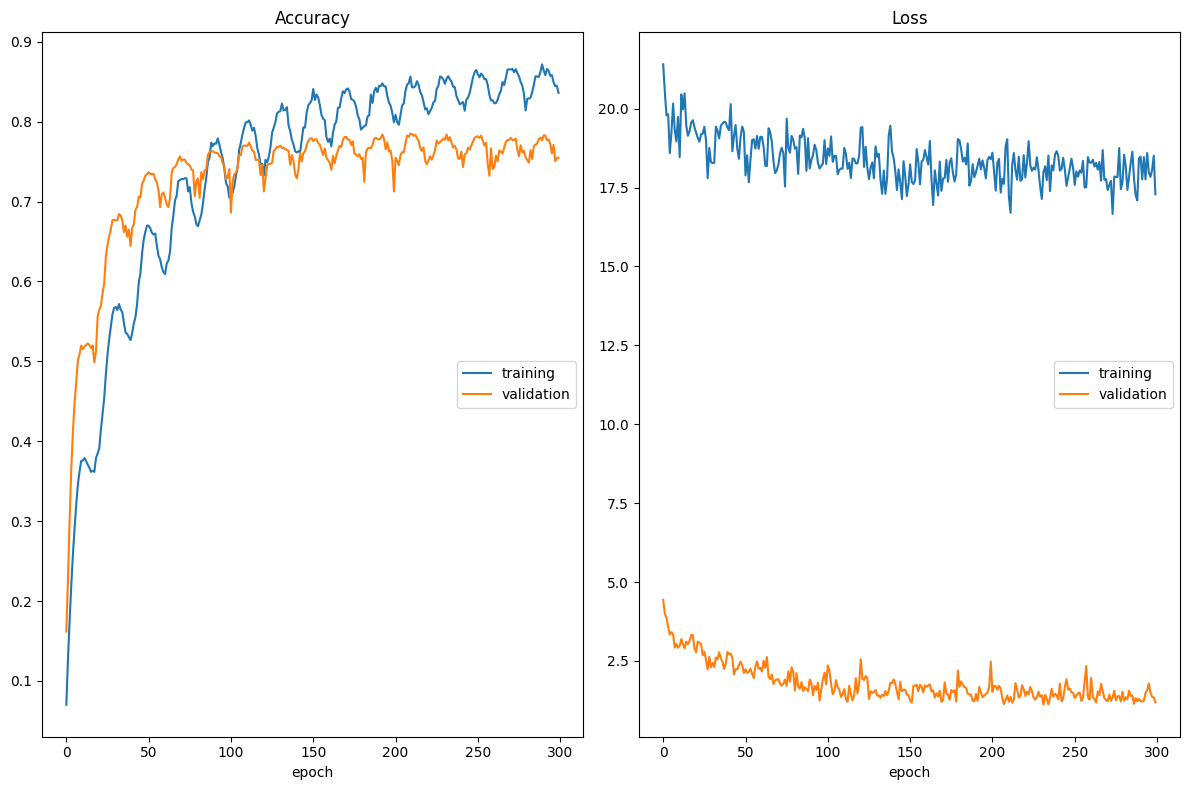

Accuracy
	training         	 (min:    0.070, max:    0.872, cur:    0.836)
	validation       	 (min:    0.162, max:    0.785, cur:    0.755)
Loss
	training         	 (min:   16.664, max:   21.402, cur:   17.286)
	validation       	 (min:    1.114, max:    4.433, cur:    1.187)


In [28]:

trainer_obj.run(kd_train_dl, kd_test_dl, EPOCH)

The comments are self-explainatory. If you do not know what a transformation does, the official documentation is your friend.
Reading documentation helps your brain.

---

| All     | [advanced_pytorch/](https://github.com/Tensor-Reloaded/AI-Learning-Hub/blob/main/resources/advanced_pytorch) |
|---------|-- |
| Current | [A complex yet simple efficient training pipeline for CIFAR-10](https://github.com/Tensor-Reloaded/AI-Learning-Hub/blob/main/resources/advanced_pytorch/ComplexYetSimpleTrainingPipeline.ipynb) |